---

[![Abrir no Google Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ppestana-supervisor/PDI_python/blob/main/topico4/notebook41.ipynb)

> **Nota importante**
>
> Este notebook é carregado diretamente a partir do repositório oficial no GitHub e é apenas para **leitura**.  
> As alterações **não ficam guardadas**.
>
> Para guardar uma versão pessoal:
> - No Colab, ir a **Ficheiro → Guardar uma cópia no Drive**.  
> - A cópia ficará disponível em `O meu Drive / Colab Notebooks`.
>
> Para colaboração:
> - Abrir a versão pessoal no Google Drive.  
> - Clicar em **Partilhar** → **Qualquer pessoa com o link pode editar** (ou adicionar os colegas manualmente).  
> - A partir daí, todos podem editar em tempo real, como num Google Docs.
>
> Para guardar resultados (imagens, ficheiros, etc.) no  Drive:
> ```python
> from google.colab import drive
> drive.mount('/content/drive')
> ```
> Depois gravar, por exemplo, em:
> ```python
> img.save('/content/drive/MyDrive/PDI_outputs/resultado.png')
> ```

---

In [ ]:
### !!! Executar esta célula primeiro, se dentro do Colab
# Quando dentro do Colab, clonar o repositório completo para garantir acesso à pasta de imagens
!git clone https://github.com/ppestana-supervisor/PDI_python.git
%cd PDI_python/topico4

# 4.1 Binarização e Limiarização

### 4.1 Binarização e Limiarização

A **binarização** é uma das operações mais fundamentais no processamento digital de imagens. O objetivo é transformar uma imagem em tons de cinzento numa imagem binária — composta apenas por dois valores possíveis (normalmente 0 e 1, ou preto e branco) — de modo a destacar regiões de interesse e simplificar análises posteriores.  

O processo que conduz à binarização chama-se **limiarização** (*thresholding*). Consiste em definir um **limiar de decisão** (*threshold*) $T$ e aplicá-lo a cada píxel da imagem. Matematicamente, a operação pode ser expressa como:

$$
g(x, y) = 
\begin{cases}
1, & \text{se } f(x, y) > T \\
0, & \text{caso contrário}
\end{cases}
$$

onde $f(x, y)$ representa a intensidade do píxel na imagem original e $g(x, y)$ o valor correspondente na imagem binarizada.

A escolha do limiar $T$ pode ser feita de forma **manual** (com base em conhecimento prévio ou observação visual do histograma) ou **automática**, através de métodos estatísticos que analisam a distribuição dos níveis de cinzento — como o método de **Otsu**, que procura o limiar que maximiza a separação entre classes (fundo e objeto).  

Em termos conceituais:
- **Limiarização** é o processo de **decisão** — encontrar o valor de $T$ que melhor separa as classes.
- **Binarização** é o **resultado da transformação** — a imagem que contém apenas dois valores, após a aplicação do limiar.

Ao longo deste capítulo, explora-se a diferença entre estas duas etapas, bem como o impacto da escolha do limiar e das características da imagem (contraste, ruído, iluminação) no resultado final. Sempre que possível, evitamos recorrer diretamente a funções prontas das bibliotecas, reimplementando os métodos de forma simplificada e de baixo nível.  
Estas reimplementações têm um propósito **pedagógico**, permitindo compreender o funcionamento interno das operações e a sua evolução conceptual — sem pretender replicar o desempenho ou a sofisticação das versões otimizadas disponíveis nas bibliotecas modernas.

## 4.1.1. Setup

Nesta célula inicial são carregadas as principais bibliotecas necessárias para o processamento e análise de imagens ao longo do notebook. Esta célula estabelece a base do ambiente de trabalho do notebook. As imagens incluídas cobrem vários tipos de conteúdo visual — desde padrões sintéticos (gradiente) a texturas naturais (face, edifício, bolacha) e cenas de referência (moedas, página, câmara). Esta diversidade permite ilustrar, ao longo dos exercícios seguintes, o comportamento dos filtros e algoritmos de segmentação em situações com diferentes níveis de ruído, contraste e complexidade estrutural.

#### Bibliotecas

A biblioteca **NumPy** é usada para operações matriciais e criação de imagens sintéticas.  
**Pillow (PIL)** é utilizada para ler e converter imagens em tons de cinzento.  
**Matplotlib** fornece as funções de visualização e controlo estético das figuras.  
O módulo **skimage** (scikit-image) disponibiliza imagens de exemplo (`data`), filtros (`filters`), e ferramentas de segmentação (`segmentation`), bem como funções de limiarização automática (`threshold_otsu` e `threshold_multiotsu`).  
A biblioteca **SciPy**, através de `ndimage`, é usada para filtros espaciais clássicos (gaussiano, uniforme, mediano).  
**OpenCV (cv2)** acrescenta operações de processamento morfológico e de contornos com elevada eficiência.  
Por fim, `label2rgb` é usada para converter mapas de rótulos em imagens coloridas, e `time` permite medir tempos de execução.  
Define-se o estilo gráfico global *seaborn-whitegrid* para manter consistência visual entre figuras.

#### Criação de Imagens Sintéticas

`img_grad` — com um gradiente horizontal de 0 a 255, útil para testar transformações de contraste e efeitos de suavização.  

#### Imagens Importadas
`img_coins`, `img_page` e `img_camera` são exemplos clássicos da biblioteca **scikit-image**, amplamente usados em tarefas de segmentação e deteção de arestas. Correspondem respetivamente a uma imagem com múltiplos objetos independentes, simples de segmentar, uma imagem que resulta de uma digitalização de um texto através de fotografia e ilustra problemas com sombras, e uma imagem com elementos geometricamente independetes.
`img_man`, `img_building` e `img_cookie` são ficheiros externos carregados da pasta `imgs/`, convertidos para escala de cinzentos através de Pillow e armazenados como matrizes NumPy. Correspondem respetivamente a um retrato genérico que ilustra algumas das maiores dificuldades no processamento, uma imagem com linhas bem definidas e uma imagem com um único objeto, facilmente separável de um fundo uniforme.

In [1]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from skimage import data, filters, segmentation
from skimage.filters import threshold_multiotsu, threshold_otsu
from scipy.ndimage import gaussian_filter, uniform_filter, median_filter
import cv2
from skimage.color import label2rgb
import time
plt.style.use('seaborn-v0_8-whitegrid')

h, w = 100, 100
img_grad = np.tile(np.arange(256, dtype=np.uint8), (h, 1))

img_coins = data.coins()
img_page = data.page()
img_camera = data.camera()
img_man = np.array(Image.open("imgs/face_tgt.png").convert("L"))
img_building = np.array(Image.open("imgs/building2.png").convert("L"))
img_cookie = np.array(Image.open("imgs/cookie.png").convert("L"))

## 4.1.2. Cálculo e visualização do histograma


Esta célula introduz o **histograma de intensidades** de uma imagem em tons de cinzento, representando a distribuição de níveis no intervalo discreto [0, 255]. Conceitualmente, o histograma aproxima a densidade de probabilidade das intensidades: para cada nível $i$, a probabilidade empírica é $p(i)=\frac{n(i)}{N}$, onde $n(i)$ é o número de píxeis com intensidade $i$ e $N$ o total de píxeis. Ao normalizar as contagens para somarem 1 obtemos um histograma probabilístico, útil para comparar imagens de dimensões distintas e para operações subsequentes (e.g., limiarização e realce de contraste).

**Descrição sequencial do código**  
1) Seleção da imagem de trabalho: atribui-se a imagem em escala de cinzentos a uma variável de conveniência.  
2) Cálculo do histograma: usa-se `np.histogram` com 256 bins uniformes sobre [0, 255] para obter contagens por bin e os respetivos limites (vetor de “bins”).  
3) Normalização: divide-se o vetor de contagens pela soma total para obter $p(i)$ com $\sum_i p(i)=1$.  
4) Preparação da figura: cria-se uma figura com dois subplots lado a lado via `plt.subplots(1, 2, figsize=(10, 4))`.

   **Subplot A (bloco 4A)** — Visualização da imagem  
   4A.1) Renderização: apresenta-se a imagem com `imshow` usando `cmap='gray'` e limites fixos de visualização $vmin=0$, $vmax=255$ para manter a escala tonal absoluta.  
   4A.2) Rotulagem e eixos: define-se o título informativo e remove-se o sistema de eixos para foco no conteúdo.

   **Subplot B (bloco 4B)** — Visualização do histograma  
   4B.1) Curva do histograma: traça-se `plot(bins[:-1], hist)` para representar a frequência normalizada por intensidade (usa-se o limite inferior de cada bin como eixo $x$).  
   4B.2) Rotulagem: definem-se título e rótulos de eixos para clarificar que o eixo $x$ é a intensidade (0–255) e o eixo $y$ a frequência normalizada.

5) Ajustes finais e renderização: aplica-se `tight_layout` para evitar sobreposições e invoca-se `show` para apresentar a figura.

**Interpretação e observações**  
A leitura combinada imagem–histograma permite relacionar conteúdo visual e distribuição tonal: concentrações à esquerda indicam imagem globalmente escura; à direita, clara; distribuições estreitas sugerem baixo contraste (intervalo de intensidades reduzido). Histogramas multimodais (vários picos) podem refletir regiões distintas na cena (materiais/iluminação). Para explorar: altere o número de bins (p.ex., 64, 128, 256) e observe o impacto na suavidade e detalhe do histograma; mantenha a normalização para comparações entre imagens de tamanhos diferentes. Como extensão, o histograma normalizado pode suportar métricas (p.ex., entropia $H=-\sum_i p(i)\log p(i)$) e limiarizações automáticas, onde a forma de $p(i)$ é determinante.

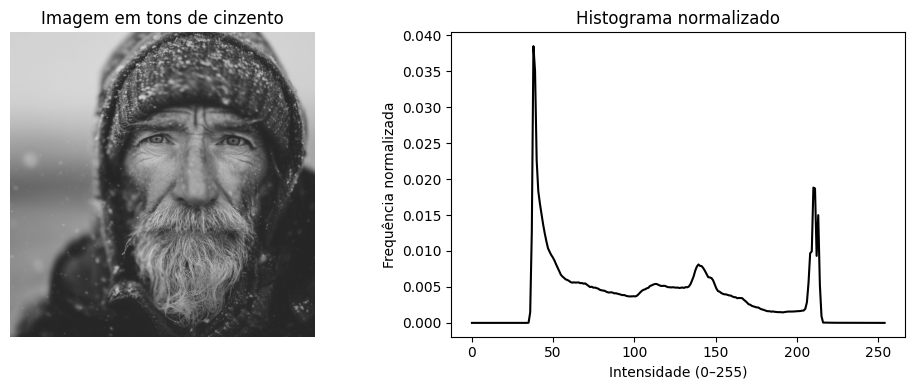

In [2]:
histImg = img_man
hist, bins = np.histogram(histImg, bins=256, range=(0, 255))
hist = hist / hist.sum()  # normalize

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].imshow(histImg, cmap='gray', vmin=0, vmax=255)
axes[0].set_title('Imagem em tons de cinzento')
axes[0].axis('off')

axes[1].plot(bins[:-1], hist, color='black')
axes[1].set_title('Histograma normalizado')
axes[1].set_xlabel('Intensidade (0–255)')
axes[1].set_ylabel('Frequência normalizada')

plt.tight_layout()
plt.show()

## 4.1.3. Binarização com limiar fixo

Esta célula demonstra o efeito do **limiar fixo** na binarização de imagens em tons de cinzento, usando um exemplo baseado numa imagem de gradiente. O processo de binarização consiste em definir um limiar $T$ tal que todos os píxeis com intensidade superior a $T$ são classificados como 1 (branco) e os restantes como 0 (preto), formalmente:  
$$
g(x,y) =
\begin{cases}
255, & \text{se } f(x,y) > T \\
0, & \text{caso contrário}
\end{cases}
$$  
Este procedimento, embora simples, é fundamental em segmentação, permitindo isolar regiões de interesse com base na intensidade. Aqui, a análise foca-se em como a escolha de $T$ influencia o resultado.

**Descrição sequencial do código**  
1) Define-se o limiar fixo $T=128$ e aplica-se a operação de comparação `(img_grad > T)`, convertendo o resultado booleano em imagem binária com valores 0 e 255.  
2) Para garantir margens uniformes nas visualizações, ambas as imagens (`img_grad` e a binarizada) são acolchoadas com um pixel de borda negra usando `np.pad`.  
3) Cria-se uma figura com dois subplots (`plt.subplots(1, 2)`):  
   **3A)** Exibe-se a imagem original (gradiente) no primeiro eixo, com escala tonal fixa entre 0 e 255.  
   **3B)** Exibe-se no segundo eixo a imagem binarizada com o limiar fixo $T=128$, para comparação direta.  
4) Num segundo bloco, testa-se a sensibilidade ao limiar usando uma lista de valores `[64, 128, 192]`. Para cada limiar, aplica-se a mesma lógica e armazena-se o resultado acolchoado numa lista `binaries_b`.  
5) Constrói-se uma figura com tantos subplots quanto o número de limiares, mais um para a imagem original:  
   **5A)** O primeiro subplot mostra a imagem original em tons de cinzento.  
   **5B)** Cada subplot seguinte mostra o resultado da binarização para um valor distinto de $T$, identificado no título.  
6) Adiciona-se um título global “Comparação de limiares fixos” e aplica-se `tight_layout()` para ajustar o espaçamento entre subplots antes de mostrar a figura.

**Interpretação e observações**  
O resultado evidencia como a posição do limiar $T$ altera radicalmente a segmentação: valores baixos (e.g., $T=64$) classificam grande parte da imagem como branca, enquanto valores altos (e.g., $T=192$) deixam apenas as regiões de maior intensidade. Este comportamento ilustra a necessidade de ajustar o limiar ao histograma ou contraste da imagem. É aconselhável observar o histograma correspondente e escolher $T$ próximo do vale entre picos, quando existem dois modos bem definidos. Experimente alterar $T$ manualmente para compreender a relação entre nível de cinzento e área segmentada; este exercício é a base de métodos automáticos como o de Otsu, que calcula o limiar ótimo sem intervenção humana.

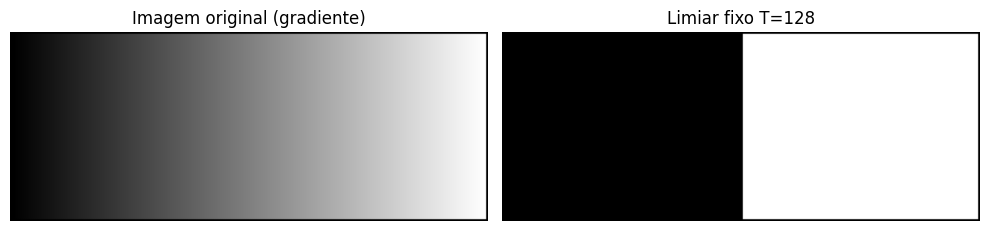

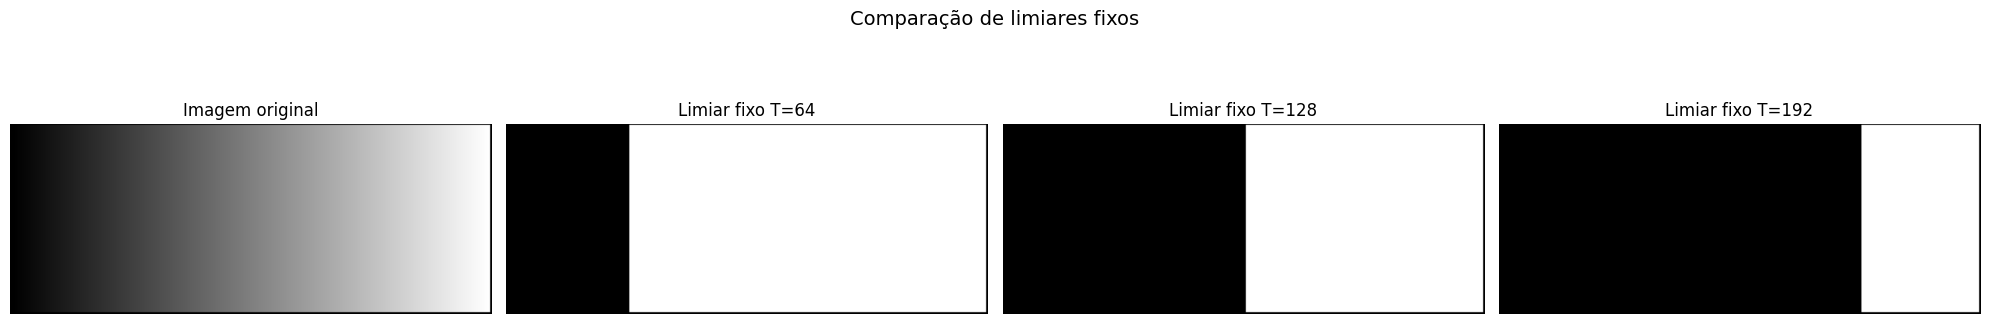

In [3]:
import numpy as np
import matplotlib.pyplot as plt

T = 128
binary_fixed = (img_grad > T).astype(np.uint8) * 255

border = 1
img_grad_b   = np.pad(img_grad,     ((border, border), (border, border)), mode='constant', constant_values=0)
binary_fix_b = np.pad(binary_fixed, ((border, border), (border, border)), mode='constant', constant_values=0)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(img_grad_b, cmap='gray', vmin=0, vmax=255)
axes[0].set_title('Imagem original (gradiente)')
axes[0].axis('off')
axes[1].imshow(binary_fix_b, cmap='gray', vmin=0, vmax=255)
axes[1].set_title(f'Limiar fixo T={T}')
axes[1].axis('off')
plt.tight_layout()
plt.show()

thresholds = [64, 128, 192]
img_grad_b = np.pad(img_grad, ((border, border), (border, border)), mode='constant', constant_values=0)

binaries_b = []
for t in thresholds:
    bin_img = (img_grad > t).astype(np.uint8) * 255
    bin_img_b = np.pad(bin_img, ((border, border), (border, border)), mode='constant', constant_values=0)
    binaries_b.append((t, bin_img_b))

fig, axes = plt.subplots(1, len(thresholds) + 1, figsize=(5 * (len(thresholds) + 1), 4))

axes[0].imshow(img_grad_b, cmap='gray', vmin=0, vmax=255)
axes[0].set_title('Imagem original')
axes[0].axis('off')

for i, (t, img_b) in enumerate(binaries_b, start=1):
    axes[i].imshow(img_b, cmap='gray', vmin=0, vmax=255)
    axes[i].set_title(f'Limiar fixo T={t}')
    axes[i].axis('off')

fig.suptitle('Comparação de limiares fixos', fontsize=14)
plt.tight_layout()
plt.show()

## 4.1.4. Binarização por picos e vales

Esta célula demonstra a implementação do **método Pico-Vale** (ou *Histogram Valley Thresholding*) para determinação automática do limiar de binarização. A ideia central é identificar os picos e vales do histograma de intensidades e escolher o limiar $T$ correspondente ao vale mais profundo entre dois picos relevantes. Esse ponto representa a intensidade que melhor separa duas classes de píxeis — por exemplo, fundo e objeto — assumindo que a imagem tem uma distribuição bimodal de intensidades. O método aproxima o raciocínio visual humano: procurar o ponto de menor frequência entre duas concentrações principais de tons.

**Descrição sequencial do código**  
1) Define-se a função `peak_valley_threshold(img, smooth_kernel=15, return_all=False)`, que calcula o limiar ideal com base na forma do histograma.  
2) Calcula-se o histograma com `np.histogram` (256 bins em [0, 255]) e normaliza-se dividindo pela soma total.  
3) Aplica-se uma suavização com convolução (`np.convolve`) usando um kernel uniforme de largura `smooth_kernel`, o que elimina flutuações de ruído e permite destacar as tendências principais.  
4) Calcula-se a derivada discreta do histograma suavizado (`np.diff`), e percorrem-se os valores para identificar:  
   - **Picos**: transições de derivada positiva para negativa.  
   - **Vales**: transições de derivada negativa para positiva.  
5) Se existirem vales, seleciona-se aquele com menor valor de frequência como limiar $T$; caso contrário, toma-se o mínimo global do histograma suavizado.  
6) Se `return_all=True`, a função devolve também o histograma suavizado, as posições dos picos e vales, além do limiar.  
7) Define-se a função auxiliar `manual_threshold(img, T)` para aplicar o limiar obtido e gerar uma imagem binária.  
8) Chama-se `peak_valley_threshold` sobre a imagem `img_coins` para obter o limiar $T$, o histograma suavizado e as listas de picos/vales.  
9) Aplica-se o limiar a duas imagens distintas: o gradiente (`img_grad`) e a imagem original (`img_coins`), produzindo `binary_valley_grad` e `binary_valley_real`.  
10) As imagens binarizadas são acolchoadas com uma borda de um pixel para apresentação consistente.  
11) Constrói-se uma figura com **duas linhas e três colunas** de subplots:  
    **Linha 1:**  
    - (1,1) Imagem original.  
    - (1,2) Histograma suavizado, exibindo a forma geral da distribuição.  
    - (1,3) Mesmo histograma, mas com os pontos de picos (verde) e vales (vermelho) assinalados graficamente.  
    **Linha 2:**  
    - (2,1) Resultado da binarização aplicada à imagem de gradiente, com o valor $T$ indicado no título.  
    - (2,2) Histograma suavizado com uma linha vertical no limiar selecionado.  
    - (2,3) Resultado da binarização da imagem real (`img_coins`) com o mesmo limiar.  
12) Define-se um título global “Método do Pico-Vale (Histogram Valley Thresholding)” e executa-se `tight_layout()` para ajustar os espaçamentos antes de mostrar a figura final.

**Interpretação e observações**  
O método Pico-Vale fornece uma forma intuitiva e automática de determinar o limiar, evitando a escolha manual. O histograma suavizado ajuda a revelar a estrutura bimodal da imagem: os picos representam classes dominantes (fundo/objeto) e o vale intermédio define o ponto ótimo de separação. É importante ajustar o parâmetro `smooth_kernel` — valores pequenos mantêm detalhes mas introduzem ruído, enquanto valores grandes podem eliminar picos relevantes. O resultado mostra como o limiar escolhido coincide com a separação natural entre regiões claras e escuras. O estudante pode experimentar com outras imagens e diferentes larguras de suavização para avaliar a robustez do método e compará-lo com abordagens mais formais, como o método de Otsu.

In [4]:
def peak_valley_threshold(img, smooth_kernel=15, return_all=False):
    """Determina o limiar pelo método Pico-Vale."""
    hist, _ = np.histogram(img, bins=256, range=(0, 255))
    hist = hist.astype(float)
    hist /= hist.sum()

    kernel = np.ones(smooth_kernel) / smooth_kernel
    hist_smooth = np.convolve(hist, kernel, mode='same')

    deriv = np.diff(hist_smooth)
    peaks, valleys = [], []
    for i in range(1, len(deriv)):
        if deriv[i-1] > 0 and deriv[i] < 0:
            peaks.append(i)
        if deriv[i-1] < 0 and deriv[i] > 0:
            valleys.append(i)

    if valleys:
        valley_counts = [hist_smooth[v] for v in valleys]
        T = valleys[int(np.argmin(valley_counts))]
    else:
        T = int(np.argmin(hist_smooth))

    if return_all:
        return T, hist_smooth, peaks, valleys
    else:
        return T

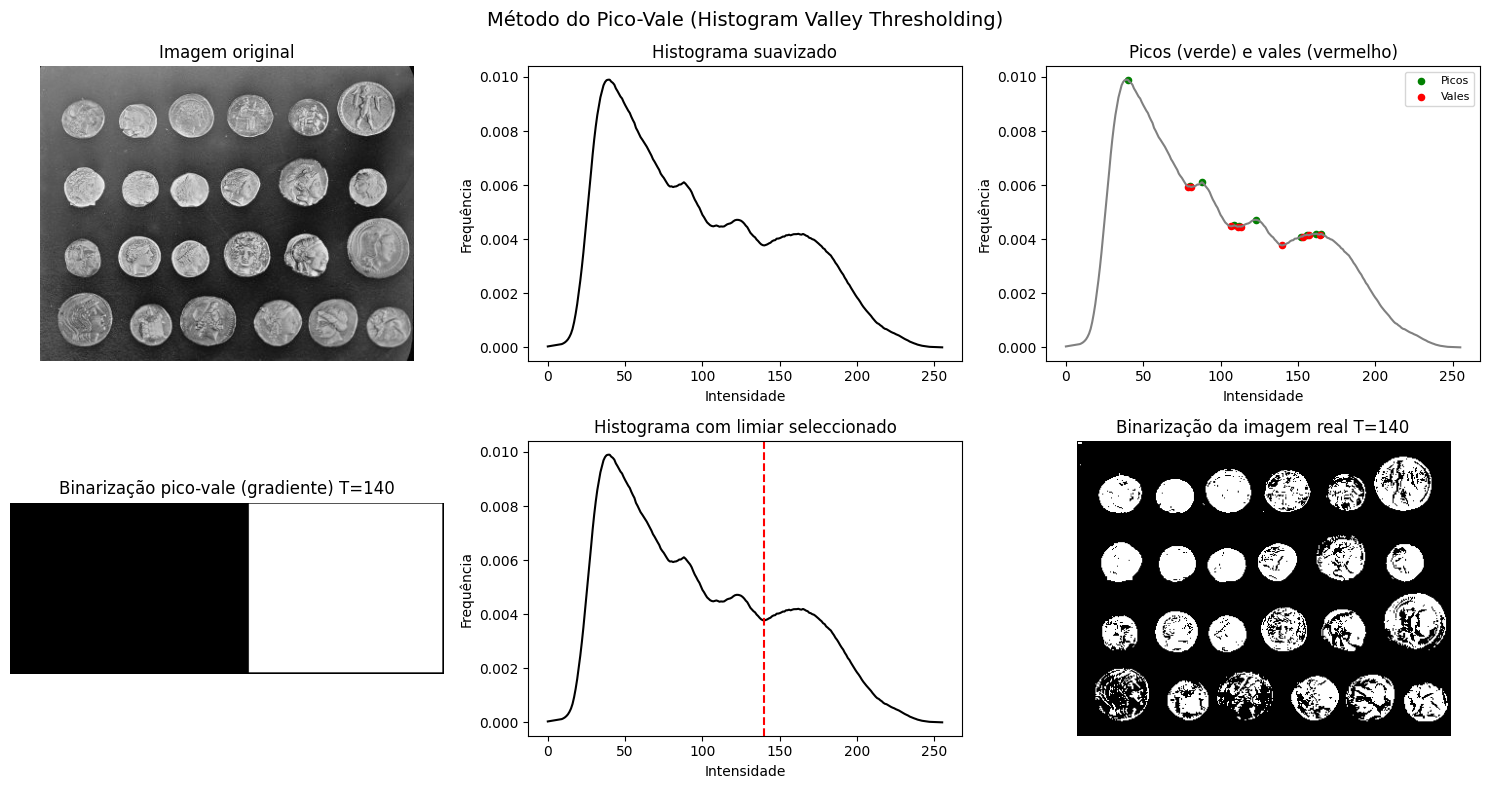

In [5]:
histImg = img_coins
hist, bins = np.histogram(histImg, bins=256, range=(0, 255))
hist = hist / hist.sum()

def manual_threshold(img, T):
    return ((img > T).astype(np.uint8) * 255)

valley_idx, hist_smooth, peaks, valleys = peak_valley_threshold(histImg, smooth_kernel=15, return_all=True)

binary_valley_grad = (img_grad > valley_idx).astype(np.uint8) * 255
binary_valley_real = (histImg > valley_idx).astype(np.uint8) * 255

border = 1
binary_valley_grad_b = np.pad(binary_valley_grad, ((border, border), (border, border)),
                              mode='constant', constant_values=0)

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

axes[0,0].imshow(histImg, cmap='gray', vmin=0, vmax=255)
axes[0,0].set_title('Imagem original')
axes[0,0].axis('off')

axes[0,1].plot(hist_smooth, color='black')
axes[0,1].set_title('Histograma suavizado')
axes[0,1].set_xlabel('Intensidade')
axes[0,1].set_ylabel('Frequência')

axes[0,2].plot(hist_smooth, color='gray')
axes[0,2].scatter(peaks,   hist_smooth[peaks],   color='green', s=20, label='Picos')
axes[0,2].scatter(valleys, hist_smooth[valleys], color='red',   s=20, label='Vales')
axes[0,2].set_title('Picos (verde) e vales (vermelho)')
axes[0,2].legend(fontsize=8)
axes[0,2].set_xlabel('Intensidade')
axes[0,2].set_ylabel('Frequência')

axes[1,0].imshow(binary_valley_grad_b, cmap='gray', vmin=0, vmax=255)
axes[1,0].set_title(f'Binarização pico-vale (gradiente) T={valley_idx}')
axes[1,0].axis('off')

axes[1,1].plot(hist_smooth, color='black')
axes[1,1].axvline(valley_idx, color='red', linestyle='--')
axes[1,1].set_title('Histograma com limiar seleccionado')
axes[1,1].set_xlabel('Intensidade')
axes[1,1].set_ylabel('Frequência')

axes[1,2].imshow(binary_valley_real, cmap='gray', vmin=0, vmax=255)
axes[1,2].set_title(f'Binarização da imagem real T={valley_idx}')
axes[1,2].axis('off')

fig.suptitle('Método do Pico-Vale (Histogram Valley Thresholding)', fontsize=14)
plt.tight_layout()
plt.show()

## 4.1.5. Método de Otsu

Esta célula apresenta uma comparação entre dois métodos automáticos de determinação de limiar: o **método Pico-Vale** e o **método de Otsu**. Ambos procuram separar duas classes de intensidades (fundo e objeto) de forma ótima, mas com critérios diferentes. O método Pico-Vale identifica empiricamente o ponto de menor frequência entre dois picos do histograma, enquanto o método de Otsu maximiza a **variância interclasse** $\sigma_b^2(T)$, procurando o limiar $T$ que melhor separa as médias das duas distribuições.

**Descrição sequencial do código**  
1) Define-se a função `otsu_threshold(img, return_all=False)`, que implementa o método de Otsu.  
2) Calcula-se o histograma da imagem e normaliza-se para obter a distribuição de probabilidade $p(i) = \frac{n(i)}{N}$.  
3) Obtêm-se as probabilidades acumuladas $\omega(t) = \sum_{i=0}^t p(i)$ e as médias acumuladas $\mu(t) = \sum_{i=0}^t i\,p(i)$.  
4) A média total é $\mu_T = \mu(255)$. Para cada possível limiar $t$, calcula-se a variância interclasse  
   $$\sigma_b^2(t) = \omega_0(t)\,\omega_1(t)\,(\mu_0(t) - \mu_1(t))^2$$  
   onde $\omega_0$ e $\omega_1$ são as probabilidades acumuladas de cada classe, e $\mu_0$, $\mu_1$ as respetivas médias condicionais.  
5) O limiar ótimo $T_{otsu}$ é o valor de $t$ que maximiza $\sigma_b^2(t)$, encontrado com `np.argmax`.  
6) As variáveis auxiliares (`sigma_b2`, `omega`, `mu`) são devolvidas se `return_all=True`.  
7) Em seguida, calcula-se também o limiar obtido pelo método Pico-Vale (`peak_valley_threshold`) para a mesma imagem, permitindo comparação direta.  
8) Aplica-se cada limiar à imagem para gerar duas binarizações (`binary_valley` e `binary_otsu`), e ambas são acolchoadas com uma borda para uniformizar a visualização.  
9) Constrói-se uma figura com **duas linhas e três colunas** de subplots:  
   **Linha 1:**  
   - (1,1) Mostra a imagem original.  
   - (1,2) Mostra o histograma suavizado com as posições dos limiares $T_{pv}$ (azul) e $T_{otsu}$ (vermelho).  
   - (1,3) Mostra a curva da variância interclasse $\sigma_b^2(T)$ com o máximo destacado, ilustrando o princípio de Otsu.  
   **Linha 2:**  
   - (2,1) Mostra a binarização pelo método Pico-Vale.  
   - (2,2) Mostra a binarização pelo método de Otsu.  
   - (2,3) Exibe uma comparação visual direta, colocando lado a lado as duas imagens binarizadas.  
10) Define-se o título global “Comparação entre Método Pico-Vale e Otsu”, aplica-se `tight_layout()` e mostra-se a figura.

**Interpretação e observações**  
A comparação revela diferenças subtis entre os dois critérios: o método Pico-Vale depende da forma do histograma e da suavização aplicada, sendo intuitivo mas sensível ao ruído; o método de Otsu é estatístico e procura maximizar a separabilidade das classes, funcionando bem quando a imagem tem distribuição claramente bimodal. Quando o histograma é irregular ou assimétrico, Otsu tende a ser mais robusto, enquanto Pico-Vale pode ser influenciado por picos espúrios. Para testar a estabilidade, pode-se alterar o parâmetro de suavização do Pico-Vale ou aplicar ambos os métodos a imagens com diferentes contrastes e ruídos, observando como o limiar $T$ se desloca. Na prática, Otsu é amplamente usado como referência para limiarização global automática.

In [6]:
def otsu_threshold(img, return_all=False):
    hist, _ = np.histogram(img.flatten(), bins=256, range=(0, 255))
    prob = hist.astype(float) / hist.sum()
    omega = np.cumsum(prob)                     # probabilidades acumuladas
    mu = np.cumsum(prob * np.arange(256))       # médias acumuladas
    mu_total = mu[-1]
    sigma_b2 = np.zeros(256)
    for t in range(1, 256):
        w0 = omega[t]
        w1 = 1 - w0
        if w0 > 0 and w1 > 0:
            mu0 = mu[t] / w0
            mu1 = (mu_total - mu[t]) / w1
            sigma_b2[t] = w0 * w1 * (mu0 - mu1) ** 2
    T_otsu = int(np.argmax(sigma_b2))

    if return_all:
        return T_otsu, sigma_b2, omega, mu
    else:
        return T_otsu

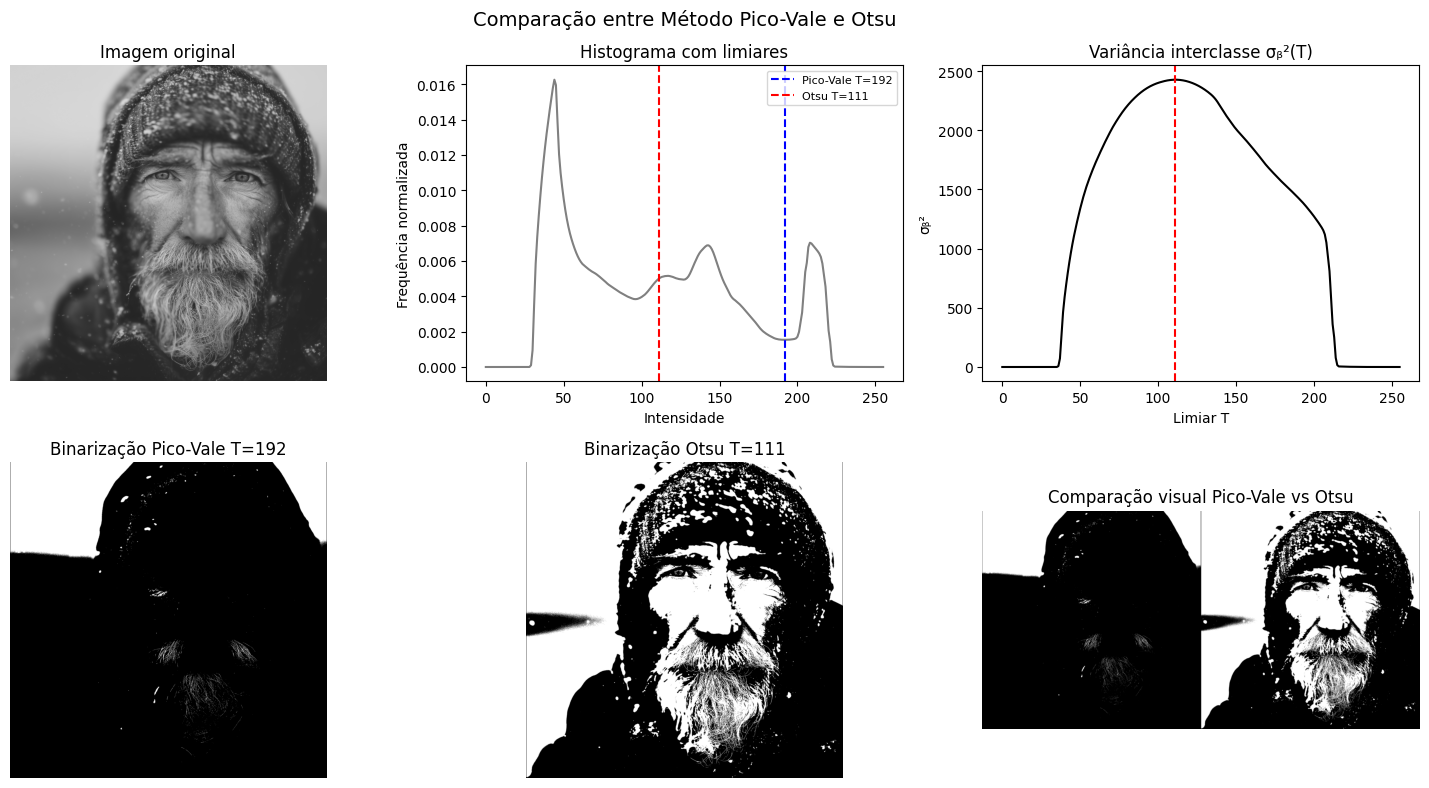

In [7]:
img_in = img_man

valley_idx, hist_smooth, peaks, valleys = peak_valley_threshold(img_in, smooth_kernel=15, return_all=True)
T_otsu, sigma_b2, omega, mu = otsu_threshold(img_in, return_all=True)

binary_valley = (img_in > valley_idx).astype(np.uint8) * 255
binary_otsu   = (img_in > T_otsu).astype(np.uint8) * 255

border = 2
binary_valley_b = np.pad(binary_valley, ((border, border), (border, border)), mode='constant', constant_values=0)
binary_otsu_b   = np.pad(binary_otsu,   ((border, border), (border, border)),   mode='constant', constant_values=0)

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

axes[0, 0].imshow(img_in, cmap='gray', vmin=0, vmax=255)
axes[0, 0].set_title('Imagem original')
axes[0, 0].axis('off')

axes[0, 1].plot(hist_smooth, color='gray')
axes[0, 1].axvline(valley_idx, color='blue', linestyle='--', label=f'Pico-Vale T={valley_idx}')
axes[0, 1].axvline(T_otsu, color='red', linestyle='--', label=f'Otsu T={T_otsu}')
axes[0, 1].set_title('Histograma com limiares')
axes[0, 1].set_xlabel('Intensidade')
axes[0, 1].set_ylabel('Frequência normalizada')
axes[0, 1].legend(fontsize=8)

axes[0, 2].plot(sigma_b2, color='black')
axes[0, 2].axvline(T_otsu, color='red', linestyle='--')
axes[0, 2].set_title('Variância interclasse σᵦ²(T)')
axes[0, 2].set_xlabel('Limiar T')
axes[0, 2].set_ylabel('σᵦ²')

axes[1, 0].imshow(binary_valley_b, cmap='gray', vmin=0, vmax=255)
axes[1, 0].set_title(f'Binarização Pico-Vale T={valley_idx}')
axes[1, 0].axis('off')

axes[1, 1].imshow(binary_otsu_b, cmap='gray', vmin=0, vmax=255)
axes[1, 1].set_title(f'Binarização Otsu T={T_otsu}')
axes[1, 1].axis('off')

axes[1, 2].imshow(np.hstack([binary_valley_b, binary_otsu_b]), cmap='gray', vmin=0, vmax=255)
axes[1, 2].set_title('Comparação visual Pico-Vale vs Otsu')
axes[1, 2].axis('off')

fig.suptitle('Comparação entre Método Pico-Vale e Otsu', fontsize=14)
plt.tight_layout()
plt.show()

## 4.1.6. Binarização Multinível

Esta célula apresenta uma extensão do método de Otsu para **segmentação multi-nível**, aplicando o princípio da maximização da variância interclasse a três classes de intensidade. Em vez de um único limiar $T$, o método procura dois limiares $T_1$ e $T_2$ que dividam o histograma em três regiões: escura, intermédia e clara. O objetivo é maximizar a separação entre as médias dessas três classes, de modo que cada uma represente um agrupamento distinto de píxeis com intensidades semelhantes.

**Descrição sequencial do código**  
1) Carrega-se a imagem `img_building` e calcula-se o histograma e a distribuição de probabilidade $p(i)=n(i)/N$.  
2) Calculam-se as probabilidades acumuladas $\omega(i)$ e as médias acumuladas $\mu(i)$, bem como a média global $\mu_T$.  
3) Inicia-se uma pesquisa exaustiva sobre todos os pares de limiares $(t_1, t_2)$, respeitando $1 \leq t_1 < t_2 \leq 255$.  
4) Para cada par, dividem-se as classes e calculam-se as suas probabilidades parciais $w_0$, $w_1$, $w_2$ e médias condicionais $\mu_0$, $\mu_1$, $\mu_2$.  
5) Avalia-se a função objetivo da variância interclasse generalizada:  
   $$
   \sigma_b^2 = w_0(\mu_0 - \mu_T)^2 + w_1(\mu_1 - \mu_T)^2 + w_2(\mu_2 - \mu_T)^2
   $$  
   O par $(t_1, t_2)$ que maximiza $\sigma_b^2$ é guardado como $(T_1, T_2)$.  
6) Em paralelo, calcula-se a solução obtida automaticamente pela função `threshold_multiotsu` da biblioteca `skimage`, que implementa o mesmo princípio de forma otimizada.  
7) Comparam-se os limiares manuais e automáticos imprimindo os resultados no terminal.  
8) As imagens são segmentadas por quantização discreta (`np.digitize`) usando os respetivos limiares, e os valores das classes são remapeados para a escala [0, 255] para visualização.  
9) Acrescenta-se uma borda de dois píxeis a cada imagem segmentada para uniformizar as dimensões.  
10) Constrói-se uma figura 2x2 com os seguintes subplots:  
    - (1,1) Imagem original em tons de cinzento.  
    - (1,2) Histograma com as posições dos limiares manuais (azul tracejado) e automáticos (vermelho pontilhado).  
    - (2,1) Resultado da segmentação multi-Otsu calculada manualmente.  
    - (2,2) Resultado da segmentação automática obtida por `skimage.threshold_multiotsu`.  
11) Define-se o título global “Segmentação multi-nível (3 classes) — Método de Otsu”, ajusta-se o layout e mostra-se a figura.

**Interpretação e observações**  
A segmentação multi-nível permite separar uma imagem em mais de duas regiões homogéneas, útil em cenas com diferentes níveis de iluminação ou materiais. Os dois limiares $T_1$ e $T_2$ identificam transições entre regiões escuras, médias e claras. O método maximiza a separabilidade estatística entre estas regiões, assumindo que o histograma pode ser decomposto em três distribuições aproximadamente distintas. O resultado manual deve coincidir quase exatamente com o do `skimage`, confirmando a correção da implementação. Experimente alterar o número de classes (por exemplo, 4) ou aplicar o método a imagens com contrastes mais complexos para observar como o número de limiares e o tempo de execução crescem rapidamente — uma limitação prática da abordagem exaustiva.

Manual:  T1=78, T2=150
skimage: T1=76, T2=146


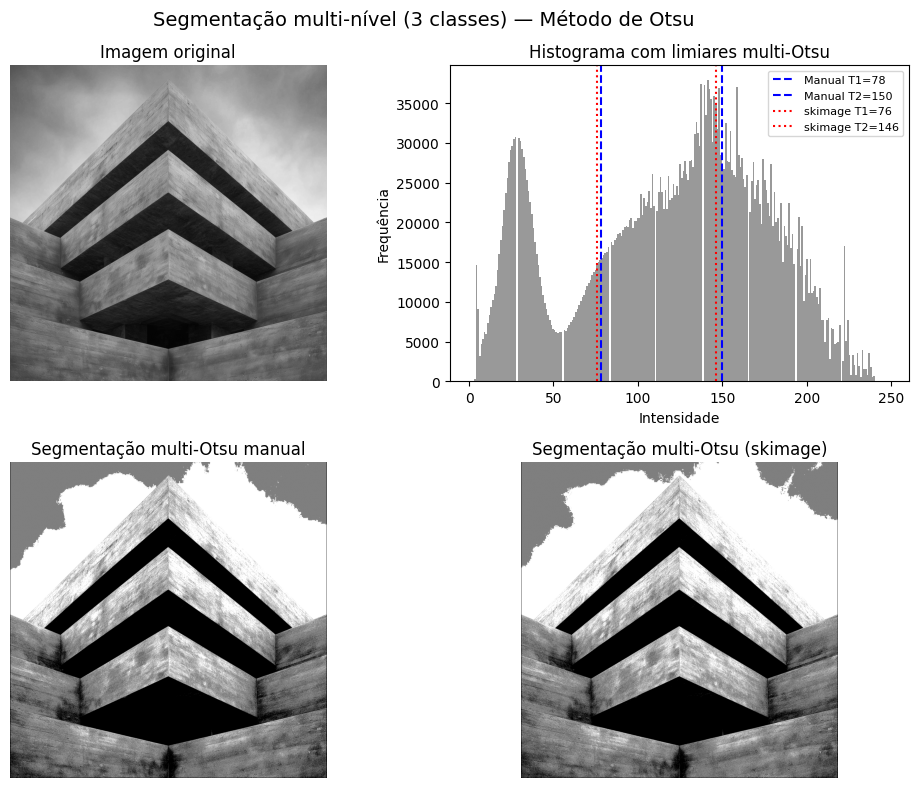

In [8]:
img_in = img_building

hist_multi, _ = np.histogram(img_in.flatten(), bins=256)
prob_multi = hist_multi.astype(float) / hist_multi.sum()
omega_multi = np.cumsum(prob_multi)
mu_multi = np.cumsum(prob_multi * np.arange(256))
mu_total_multi = mu_multi[-1]

best_sigma_multi = 0
best_t1, best_t2 = 0, 0
for t1 in range(1, 255):
    for t2 in range(t1 + 1, 256):
        w0 = omega_multi[t1]
        w1 = omega_multi[t2] - omega_multi[t1]
        w2 = 1 - omega_multi[t2]
        if w0 > 0 and w1 > 0 and w2 > 0:
            mu0 = mu_multi[t1] / w0
            mu1 = (mu_multi[t2] - mu_multi[t1]) / w1
            mu2 = (mu_total_multi - mu_multi[t2]) / w2
            sigma = (w0 * (mu0 - mu_total_multi) ** 2 +
                     w1 * (mu1 - mu_total_multi) ** 2 +
                     w2 * (mu2 - mu_total_multi) ** 2)
            if sigma > best_sigma_multi:
                best_sigma_multi = sigma
                best_t1, best_t2 = t1, t2

thresholds_skimage = threshold_multiotsu(img_in, classes=3)
t1_sk, t2_sk = thresholds_skimage

print(f"Manual:  T1={best_t1}, T2={best_t2}")
print(f"skimage: T1={t1_sk}, T2={t2_sk}")

thresholds_manual = [best_t1, best_t2]
segmented_manual = np.digitize(img_in, thresholds_manual)
segmented_manual_display = (segmented_manual / segmented_manual.max() * 255).astype(np.uint8)

thresholds_auto = [t1_sk, t2_sk]
segmented_auto = np.digitize(img_in, thresholds_auto)
segmented_auto_display = (segmented_auto / segmented_auto.max() * 255).astype(np.uint8)

border = 2
segmented_manual_b = np.pad(segmented_manual_display, ((border, border), (border, border)),
                            mode='constant', constant_values=0)
segmented_auto_b   = np.pad(segmented_auto_display, ((border, border), (border, border)),
                            mode='constant', constant_values=0)

fig, axes = plt.subplots(2, 2, figsize=(10, 8))

axes[0, 0].imshow(img_in, cmap='gray', vmin=0, vmax=255)
axes[0, 0].set_title('Imagem original')
axes[0, 0].axis('off')

axes[0, 1].hist(img_in.ravel(), bins=256, color='gray', alpha=0.8)
axes[0, 1].axvline(best_t1, color='blue', linestyle='--', label=f'Manual T1={best_t1}')
axes[0, 1].axvline(best_t2, color='blue', linestyle='--', label=f'Manual T2={best_t2}')
axes[0, 1].axvline(t1_sk, color='red', linestyle=':', label=f'skimage T1={t1_sk}')
axes[0, 1].axvline(t2_sk, color='red', linestyle=':', label=f'skimage T2={t2_sk}')
axes[0, 1].set_title('Histograma com limiares multi-Otsu')
axes[0, 1].set_xlabel('Intensidade')
axes[0, 1].set_ylabel('Frequência')
axes[0, 1].legend(fontsize=8)

axes[1, 0].imshow(segmented_manual_b, cmap='gray', vmin=0, vmax=255)
axes[1, 0].set_title('Segmentação multi-Otsu manual')
axes[1, 0].axis('off')

axes[1, 1].imshow(segmented_auto_b, cmap='gray', vmin=0, vmax=255)
axes[1, 1].set_title('Segmentação multi-Otsu (skimage)')
axes[1, 1].axis('off')

fig.suptitle('Segmentação multi-nível (3 classes) — Método de Otsu', fontsize=14)
plt.tight_layout()
plt.show()

## 4.1.7 Limiarização local por blocos

Esta célula compara métodos de **limiarização global e local (adaptativa)**, destacando as diferenças entre uma abordagem que usa um único limiar para toda a imagem (Otsu) e abordagens que ajustam o limiar de forma dinâmica em cada região, com base nas propriedades locais de brilho e contraste. Este tipo de processamento é essencial em imagens com iluminação não uniforme, como documentos digitalizados ou superfícies parcialmente sombreadas, em que um único limiar global não consegue separar corretamente o texto do fundo.

**Descrição sequencial do código**  
1) A imagem `img_page` é carregada, convertida para `uint8`, e suavizada com um filtro gaussiano (`gaussian_filter`) de $\sigma=1$ para reduzir ruído de alta frequência antes da limiarização.  
2) Aplica-se o método global de Otsu (`otsu_threshold`), que determina um único valor $T_{otsu}$ para toda a imagem. O resultado binarizado é obtido com `(img_pre > T_otsu)`.  
3) Define-se a função `local_mean_threshold(img, w, C)`, que implementa o método adaptativo baseado na **média local**.  
   - Para cada píxel, calcula-se a média $m(x,y)$ numa janela deslizante de dimensão $w\times w$.  
   - O limiar local é então $T(x,y) = m(x,y) - C$, e o píxel é classificado como branco se $f(x,y) > T(x,y)$.  
4) Define-se a função `sauvola_threshold(img, w, k, R)`, que melhora o método anterior incorporando o desvio-padrão local $s(x,y)$:  
   $$
   T(x,y) = m(x,y)\left[1 + k\left(\frac{s(x,y)}{R} - 1\right)\right]
   $$  
   onde $k$ controla a sensibilidade ao contraste e $R$ é o desvio-padrão dinâmico máximo (tipicamente 128).  
5) Aplica-se o método da média (`local_mean_threshold`) e o de Sauvola (`sauvola_threshold`), ambos com $w=31$.  
6) Para melhorar a suavidade do mapa de limiares de Sauvola, aplica-se um filtro mediano (`median_filter`) de 7×7, obtendo um limiar mais estável nas transições.  
7) As imagens binarizadas e os mapas de limiar resultantes são acolchoados com uma borda de 2 píxeis para visualização consistente.  
8) É definida a função auxiliar `norm255` para normalizar mapas de limiar para a escala [0, 255], permitindo visualização em tons de cinzento.  
9) Cria-se uma figura com **duas linhas e três colunas** de subplots:  
   - (1,1) Imagem original em tons de cinzento.  
   - (1,2) Resultado do método global de Otsu, mostrando o limiar $T_{otsu}$.  
   - (1,3) Método adaptativo pela média local ($w=31$, $C=5$).  
   - (2,1) Método de Sauvola ($w=31$, $k=0.2$).  
   - (2,2) Versão de Sauvola com suavização adicional no mapa $T$.  
   - (2,3) Comparação visual entre o **mapa de limiares** (à esquerda) e a **imagem binarizada correspondente** (à direita), ambos derivados do mesmo $T(x,y)$.  
10) Define-se o título global “Limiarização local (janela deslizante) vs global” e exibe-se a figura com `tight_layout()`.

**Interpretação e observações**  
Esta demonstração ilustra como a limiarização local resolve problemas de iluminação irregular: enquanto o método global (Otsu) falha em regiões escuras ou claras da imagem, os métodos locais ajustam-se às variações de brilho. O método da média local é simples e eficaz quando o contraste é elevado, mas pode falhar em regiões de baixo contraste. O método de Sauvola é mais robusto, pois ajusta dinamicamente o limiar conforme a variabilidade local, preservando melhor detalhes finos e texto. O filtro mediano adicional suaviza transições abruptas entre janelas, reduzindo ruído binário. Recomenda-se experimentar diferentes tamanhos de janela ($w$) e parâmetros ($C$, $k$, $R$) para observar o equilíbrio entre sensibilidade local e estabilidade visual, especialmente em imagens com textura ou sombras pronunciadas.

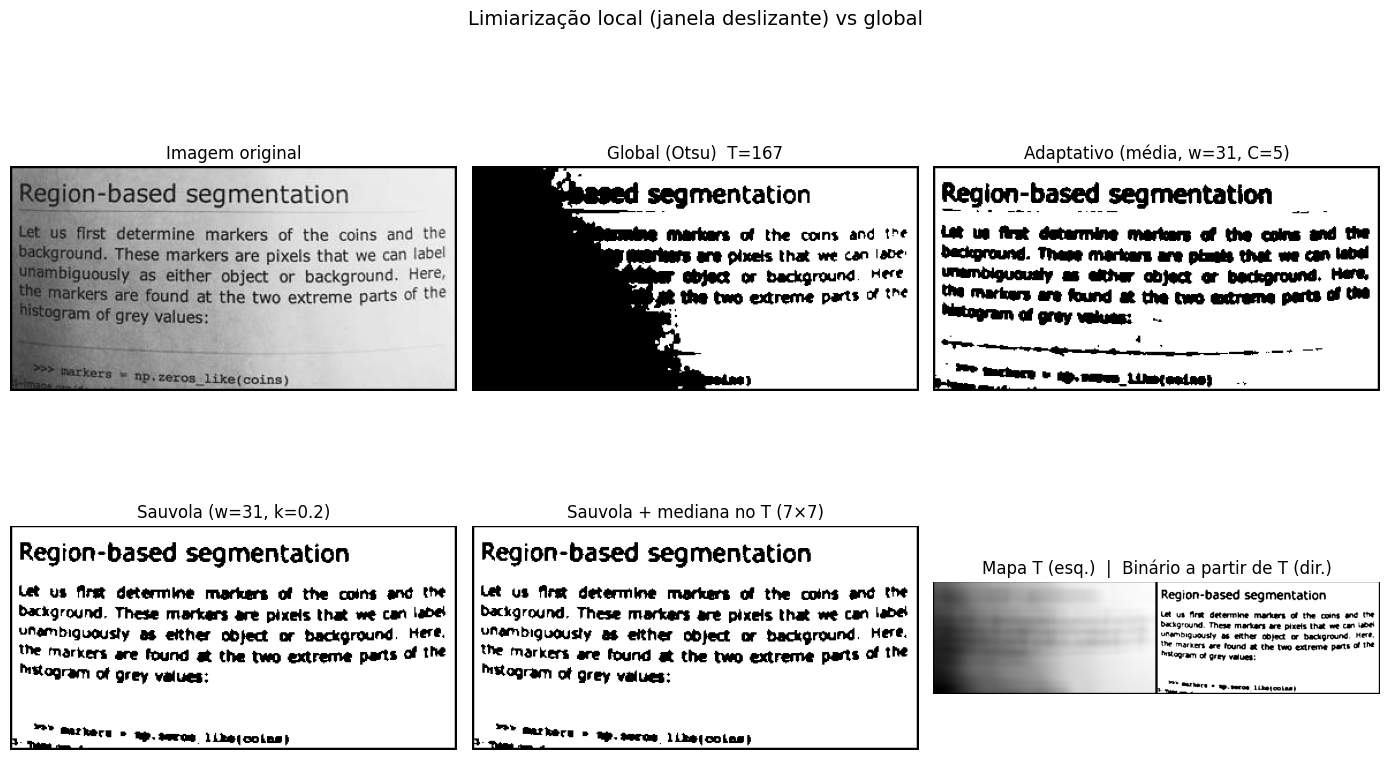

In [9]:
img_in = img_page
img_in = img_in.astype(np.uint8)
img_pre = gaussian_filter(img_in, sigma=1)

T_otsu = otsu_threshold(img_pre)
bin_otsu = (img_pre > T_otsu).astype(np.uint8) * 255

def local_mean_threshold(img, w=31, C=5):
    m = uniform_filter(img.astype(np.float32), size=w, mode="reflect")
    T = m - C
    return (img > T).astype(np.uint8) * 255, T

def sauvola_threshold(img, w=31, k=0.2, R=128):
    f = img.astype(np.float32)
    m  = uniform_filter(f, size=w, mode="reflect")
    m2 = uniform_filter(f*f, size=w, mode="reflect")
    s  = np.sqrt(np.clip(m2 - m*m, 0, None))
    T  = m * (1 + k * (s / R - 1))
    return (img > T).astype(np.uint8) * 255, T

bin_mean, T_mean = local_mean_threshold(img_pre, w=31, C=5)
bin_sauv, T_sauv = sauvola_threshold(img_pre, w=31, k=0.2, R=128)

T_sauv_smooth = median_filter(T_sauv, size=7)
bin_sauv_sm = (img_pre > T_sauv_smooth).astype(np.uint8) * 255

def add_border(a, px=2, val=0):
    return np.pad(a, ((px, px), (px, px)), mode="constant", constant_values=val)

img_b       = add_border(img_in)
bin_otsu_b  = add_border(bin_otsu)
bin_mean_b  = add_border(bin_mean)
bin_sauv_b  = add_border(bin_sauv)
bin_sauv2_b = add_border(bin_sauv_sm)

def norm255(x):
    x = x.astype(np.float32)
    return ((x - x.min()) / (x.max() - x.min() + 1e-8) * 255).astype(np.uint8)

Tmap_b = add_border(norm255(T_sauv_smooth))

fig, axes = plt.subplots(2, 3, figsize=(14, 9))

axes[0,0].imshow(img_b, cmap='gray', vmin=0, vmax=255)
axes[0,0].set_title('Imagem original'); axes[0,0].axis('off')

axes[0,1].imshow(bin_otsu_b, cmap='gray', vmin=0, vmax=255)
axes[0,1].set_title(f'Global (Otsu)  T={T_otsu}'); axes[0,1].axis('off')

axes[0,2].imshow(bin_mean_b, cmap='gray', vmin=0, vmax=255)
axes[0,2].set_title('Adaptativo (média, w=31, C=5)'); axes[0,2].axis('off')

axes[1,0].imshow(bin_sauv_b, cmap='gray', vmin=0, vmax=255)
axes[1,0].set_title('Sauvola (w=31, k=0.2)'); axes[1,0].axis('off')

axes[1,1].imshow(bin_sauv2_b, cmap='gray', vmin=0, vmax=255)
axes[1,1].set_title('Sauvola + mediana no T (7×7)'); axes[1,1].axis('off')

# Mapa de limiares (grayscale) + binário reconstituído a partir do mesmo T
Tmap_vis = norm255(T_sauv_smooth)
bin_from_T = (img_pre > T_sauv_smooth).astype(np.uint8) * 255

axes[1,2].imshow(np.hstack([add_border(Tmap_vis), add_border(bin_from_T)]),
                 cmap='gray', vmin=0, vmax=255)
axes[1,2].set_title('Mapa T (esq.)  |  Binário a partir de T (dir.)')
axes[1,2].axis('off')

fig.suptitle('Limiarização local (janela deslizante) vs global', fontsize=14)
plt.tight_layout(); plt.show()

## 4.1.8 Binarização Adaptativa

Esta célula demonstra e compara os resultados da **limiarização adaptativa** (média e gaussiana) com o método **global de Otsu**, enfatizando a influência dos parâmetros de janela e correção constante. A limiarização adaptativa calcula um limiar distinto para cada região da imagem, ajustando-se localmente ao brilho e contraste, o que é especialmente útil em documentos, texturas ou superfícies mal iluminadas. A comparação permite visualizar o efeito dos parâmetros e as regiões em que os métodos divergem.

**Descrição sequencial do código**  
1) A imagem `img_page` é carregada, normalizada para a escala [0, 255] e convertida para `uint8`.  
2) Aplica-se o método de Otsu (`otsu_threshold`) para determinar o limiar global $T_{otsu}$, seguido da binarização `(img_in > T_otsu)`.  
3) Define-se o tamanho da janela (`blockSize=35`) e a constante de correção (`C=5`). Estes parâmetros controlam a sensibilidade local:  
   - `blockSize` deve ser ímpar e define a dimensão da vizinhança usada no cálculo do limiar local.  
   - `C` é subtraído da média local ou média ponderada, ajustando o limiar para compensar variações de iluminação.  
4) Aplica-se `cv2.adaptiveThreshold` em duas variantes:  
   - `cv2.ADAPTIVE_THRESH_MEAN_C`: o limiar é a média simples das intensidades na vizinhança menos $C$.  
   - `cv2.ADAPTIVE_THRESH_GAUSSIAN_C`: o limiar é uma média ponderada com pesos gaussianos centrados no píxel, resultando em transições mais suaves.  
5) Calcula-se um mapa de diferenças binárias entre o resultado adaptativo médio e o Otsu global (`diff_map`), e cria-se uma sobreposição colorida (`overlay`) marcando em vermelho as regiões onde os dois métodos divergem.  
6) As imagens resultantes são acolchoadas com uma borda de 2 píxeis para apresentação uniforme.  
7) Cria-se uma figura 2×3 com os seguintes subplots:  
   - (1,1) Imagem original.  
   - (1,2) Limiarização adaptativa pela média.  
   - (1,3) Limiarização adaptativa gaussiana.  
   - (2,1) Variação de parâmetros: pequenas janelas de amostra mostrando os efeitos combinados de `blockSize` e `C` sobre o método da média.  
   - (2,2) Resultado do método global de Otsu, com o limiar $T_{otsu}$ no título.  
   - (2,3) Mapa de diferenças (em vermelho) entre o método adaptativo e Otsu.  
8) Define-se o título global “Limiarização adaptativa: média e gaussiana vs Otsu global” e mostra-se a figura final com `tight_layout()`.

**Interpretação e observações**  
Esta comparação mostra que os métodos adaptativos são superiores quando a iluminação é irregular: Otsu tende a falhar nas zonas escuras ou muito claras, enquanto os métodos locais ajustam-se ao contexto de cada região. A variante gaussiana geralmente produz fronteiras mais naturais e menos ruído do que a média simples. O parâmetro `C` controla a agressividade: valores maiores tornam o resultado mais escuro (limiar mais baixo), enquanto `blockSize` influencia o grau de suavização — janelas pequenas reagem rapidamente a variações locais, mas podem amplificar ruído. A figura de diferenças em vermelho permite observar onde o limiar adaptativo corrige falhas do Otsu. Recomenda-se ajustar iterativamente `blockSize` e `C` conforme a textura e contraste da imagem, especialmente em tarefas como reconhecimento de texto ou digitalização de manuscritos.

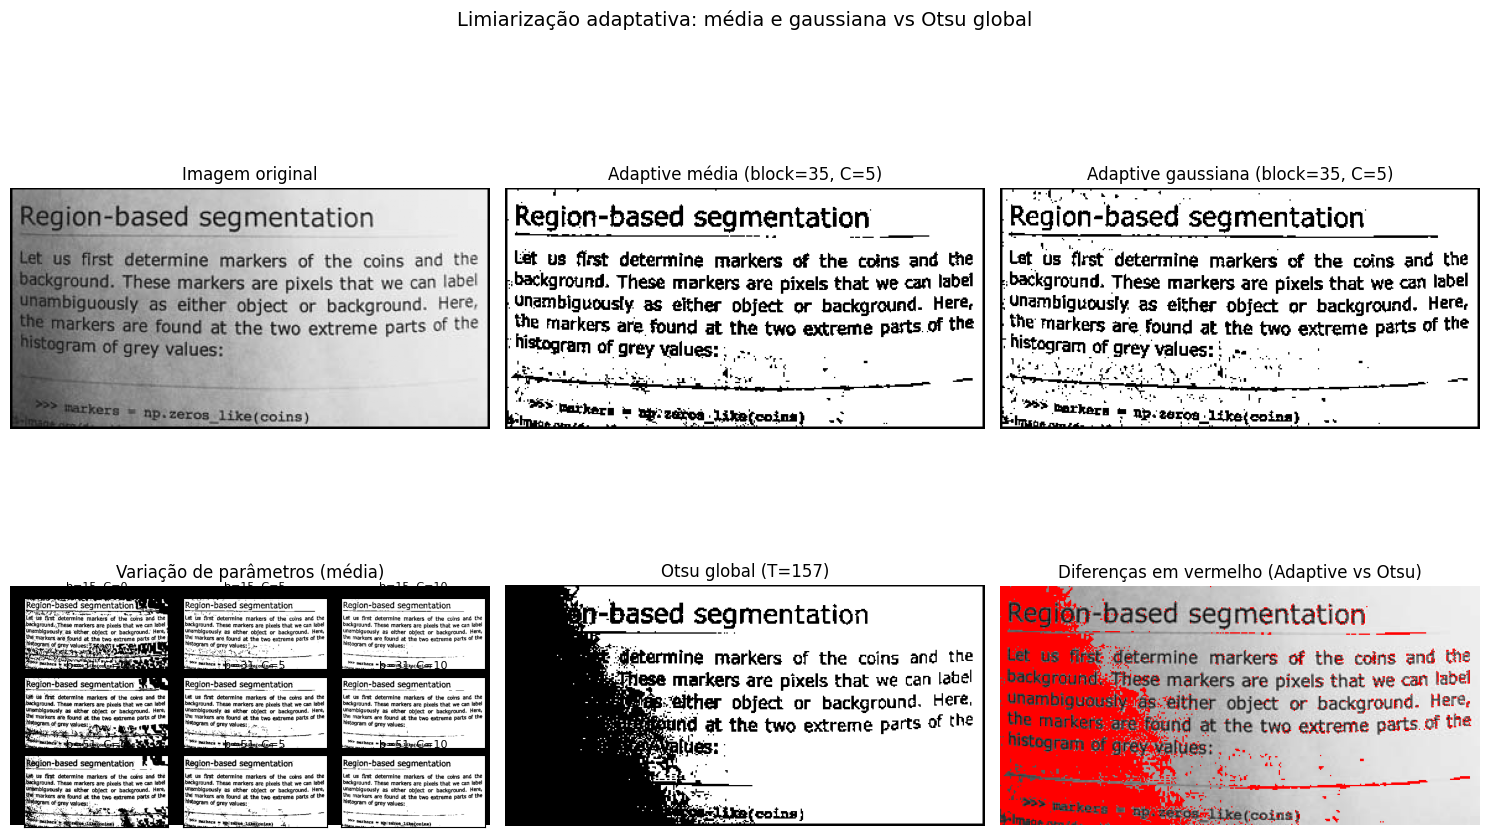

In [10]:
img_in = img_page
img_in = (img_in / img_in.max() * 255).astype(np.uint8)

T_otsu = otsu_threshold(img_in)
binary_otsu = (img_in > T_otsu).astype(np.uint8) * 255

blockSize = 35
C = 5
adaptive_mean = cv2.adaptiveThreshold(img_in, 255, cv2.ADAPTIVE_THRESH_MEAN_C,
                                      cv2.THRESH_BINARY, blockSize, C)
adaptive_gauss = cv2.adaptiveThreshold(img_in, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                       cv2.THRESH_BINARY, blockSize, C)

block_sizes = [15, 31, 51]
Cs = [0, 5, 10]

diff_map = (binary_otsu != adaptive_mean).astype(np.uint8)
overlay = cv2.cvtColor(img_in, cv2.COLOR_GRAY2BGR)
overlay[diff_map > 0] = [255, 0, 0]

def add_border(img, px=2, val=0):
    return np.pad(img, ((px, px), (px, px)), mode="constant", constant_values=val)

img_b = add_border(img_in)
binary_otsu_b = add_border(binary_otsu)
adaptive_mean_b = add_border(adaptive_mean)
adaptive_gauss_b = add_border(adaptive_gauss)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

axes[0,0].imshow(img_b, cmap='gray', vmin=0, vmax=255)
axes[0,0].set_title('Imagem original')
axes[0,0].axis('off')

axes[0,1].imshow(adaptive_mean_b, cmap='gray', vmin=0, vmax=255)
axes[0,1].set_title(f'Adaptive média (block={blockSize}, C={C})')
axes[0,1].axis('off')

axes[0,2].imshow(adaptive_gauss_b, cmap='gray', vmin=0, vmax=255)
axes[0,2].set_title(f'Adaptive gaussiana (block={blockSize}, C={C})')
axes[0,2].axis('off')

axes[1,0].imshow(np.ones_like(img_in)*255, cmap='gray')  # fundo branco
axes[1,0].set_title('Variação de parâmetros (média)')
axes[1,0].axis('off')

for i, b in enumerate(block_sizes):
    for j, c in enumerate(Cs):
        res = cv2.adaptiveThreshold(img_in, 255, cv2.ADAPTIVE_THRESH_MEAN_C,
                                    cv2.THRESH_BINARY, b, c)
        x = 10 + j*70; y = 20 + i*70
        h, w = 60, 60
        inset = axes[1,0].inset_axes([j*0.33+0.03, 0.65-i*0.33, 0.3, 0.3])
        inset.imshow(res, cmap='gray', vmin=0, vmax=255)
        inset.set_xticks([]); inset.set_yticks([])
        inset.set_title(f'b={b}, C={c}', fontsize=8)

axes[1,1].imshow(binary_otsu_b, cmap='gray', vmin=0, vmax=255)
axes[1,1].set_title(f'Otsu global (T={T_otsu})')
axes[1,1].axis('off')

axes[1,2].imshow(overlay)
axes[1,2].set_title('Diferenças em vermelho (Adaptive vs Otsu)')
axes[1,2].axis('off')

fig.suptitle('Limiarização adaptativa: média e gaussiana vs Otsu global', fontsize=14)
plt.tight_layout()
plt.show()

## 4.1.9 Gradiente e preparação para métodos regionais

Esta célula revisita a aplicação do **operador de Sobel** para a deteção de arestas, uma técnica clássica de derivação espacial utilizada em processamento de imagem. O método calcula aproximações discretas das derivadas parciais em direções horizontal e vertical, combinando-as depois para determinar a magnitude do gradiente — uma medida da variação de intensidade em cada ponto. A binarização final permite destacar as regiões de transição rápida de intensidade, que correspondem a arestas estruturais na imagem.

**Descrição sequencial do código**  
1) A imagem `img_cookie` é carregada, normalizada para a escala [0, 255] e convertida para `uint8`.  
2) Definem-se as máscaras Sobel horizontais e verticais, `sobel_x` e `sobel_y`, que estimam as derivadas $\partial f / \partial x$ e $\partial f / \partial y$ através de convolução discreta 3×3.  
3) A imagem é acolchoada com uma borda de 1 píxel (`np.pad`) usando replicação de borda (`mode='edge'`) para permitir a convolução nas margens.  
4) Inicializam-se as matrizes `gx` e `gy` para armazenar as componentes horizontal e vertical do gradiente.  
5) Um duplo ciclo percorre a imagem e, para cada posição $(i,j)$, extrai uma região 3×3 e calcula:  
   - $G_x(i,j) = \sum_{u,v} f(i+u,j+v) \cdot S_x(u,v)$  
   - $G_y(i,j) = \sum_{u,v} f(i+u,j+v) \cdot S_y(u,v)$  
   resultando nas derivadas aproximadas em cada direção.  
6) A magnitude do gradiente é obtida como $G(i,j) = \sqrt{G_x(i,j)^2 + G_y(i,j)^2}$, representando a intensidade das variações locais.  
7) O gradiente é normalizado para [0, 1] e limiarizado com um valor ajustável `edge_threshold = 0.4`, gerando uma imagem binária das arestas:  
   $$
   E(i,j) =
   \begin{cases}
   255, & \text{se } \frac{G(i,j)}{G_{max}} > 0.4 \\
   0, & \text{caso contrário}
   \end{cases}
   $$  
8) Define-se a função auxiliar `add_border` para acolchoar as imagens apresentadas e evitar cortes nas margens.  
9) Cria-se uma figura 2×3 com os seguintes subplots:  
   - (1,1) Imagem original.  
   - (1,2) Componente horizontal do gradiente ($G_x$), que realça arestas verticais.  
   - (1,3) Componente vertical ($G_y$), que realça arestas horizontais.  
   - (2,1) Magnitude do gradiente, combinando ambas as direções.  
   - (2,2) Gradiente normalizado entre 0 e 255.  
   - (2,3) Resultado final da binarização de arestas com o limiar definido.  
10) Adiciona-se o título global “Deteção de arestas com operador de Sobel” e mostra-se a figura.

**Interpretação e observações**  
O operador de Sobel atua como um filtro direcional que combina suavização e diferenciação, reduzindo o ruído ao mesmo tempo que deteta bordas. As imagens de $G_x$ e $G_y$ permitem identificar a orientação das arestas: linhas verticais produzem resposta forte em $G_x$, e horizontais em $G_y$. A magnitude do gradiente fornece uma visão global da estrutura. O limiar `edge_threshold` controla a sensibilidade: valores mais baixos revelam mais detalhes (incluindo ruído), enquanto valores mais altos retêm apenas as arestas mais marcadas. Experimente variar este limiar ou substituir as máscaras Sobel por Prewitt ou Scharr para observar diferenças de nitidez e robustez.

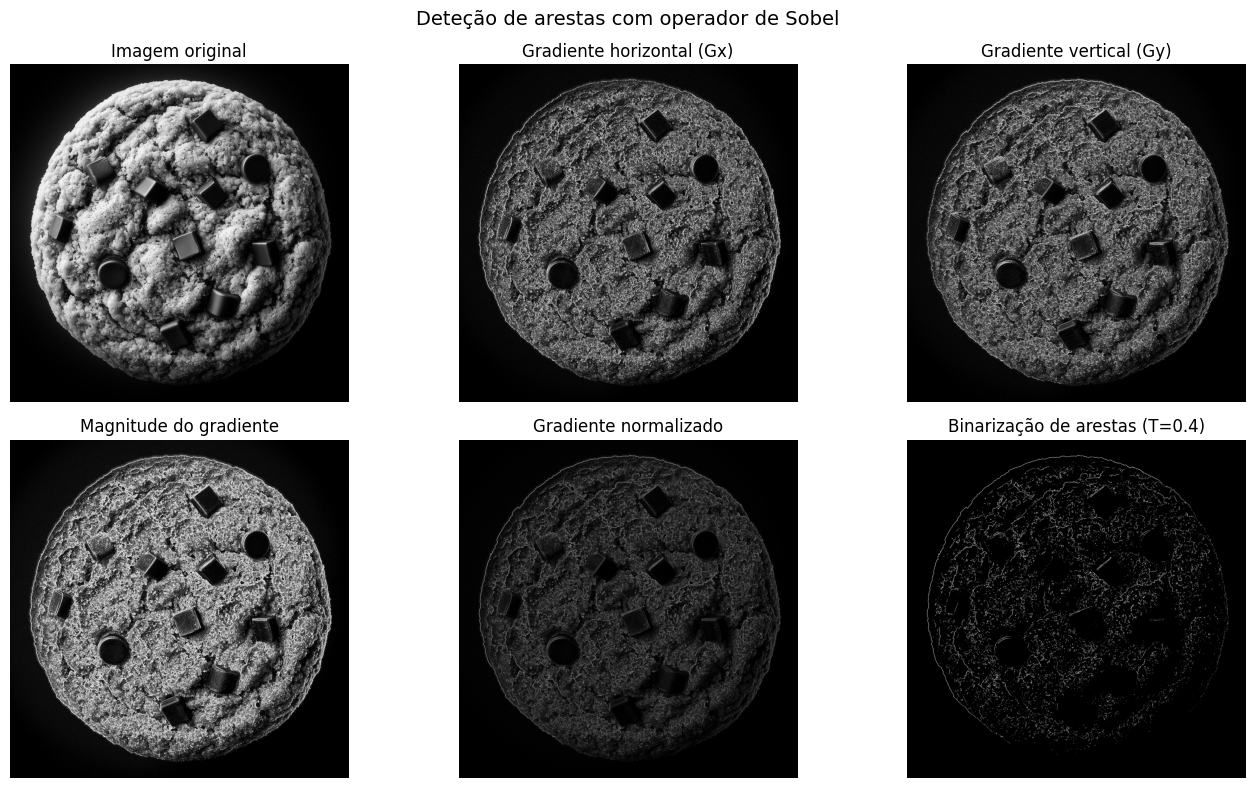

In [11]:
img_in = img_cookie
img_in = (img_in / img_in.max() * 255).astype(np.uint8)

sobel_x = np.array([[-1, 0, 1],
                    [-2, 0, 2],
                    [-1, 0, 1]], dtype=float)
sobel_y = np.array([[-1, -2, -1],
                    [0, 0, 0],
                    [1, 2, 1]], dtype=float)

padded_img = np.pad(img_in.astype(float), 1, mode='edge')
gx = np.zeros_like(img_in, dtype=float)
gy = np.zeros_like(img_in, dtype=float)

for i in range(img_in.shape[0]):
    for j in range(img_in.shape[1]):
        region = padded_img[i:i+3, j:j+3]
        gx[i, j] = np.sum(region * sobel_x)
        gy[i, j] = np.sum(region * sobel_y)

grad_mag = np.hypot(gx, gy)

norm_grad = grad_mag / (grad_mag.max() + 1e-8)
edge_threshold = 0.4  # ajustável
edges_binary = (norm_grad > edge_threshold).astype(np.uint8) * 255

def add_border(img, px=2, val=0):
    return np.pad(img, ((px, px), (px, px)), mode='constant', constant_values=val)

img_b = add_border(img_in)
gx_b = add_border(np.clip(np.abs(gx), 0, 255))
gy_b = add_border(np.clip(np.abs(gy), 0, 255))
grad_b = add_border(np.clip(grad_mag, 0, 255))
norm_b = add_border((norm_grad * 255).astype(np.uint8))
edges_b = add_border(edges_binary)

fig, axes = plt.subplots(2, 3, figsize=(14, 8))

axes[0,0].imshow(img_b, cmap='gray', vmin=0, vmax=255)
axes[0,0].set_title('Imagem original')
axes[0,0].axis('off')

axes[0,1].imshow(gx_b, cmap='gray')
axes[0,1].set_title('Gradiente horizontal (Gx)')
axes[0,1].axis('off')

axes[0,2].imshow(gy_b, cmap='gray')
axes[0,2].set_title('Gradiente vertical (Gy)')
axes[0,2].axis('off')

axes[1,0].imshow(grad_b, cmap='gray')
axes[1,0].set_title('Magnitude do gradiente')
axes[1,0].axis('off')

axes[1,1].imshow(norm_b, cmap='gray', vmin=0, vmax=255)
axes[1,1].set_title('Gradiente normalizado')
axes[1,1].axis('off')

axes[1,2].imshow(edges_b, cmap='gray', vmin=0, vmax=255)
axes[1,2].set_title(f'Binarização de arestas (T={edge_threshold})')
axes[1,2].axis('off')

fig.suptitle('Deteção de arestas com operador de Sobel', fontsize=14)
plt.tight_layout()
plt.show()

## 4.1.10 Crescimento de regiões

Esta célula implementa o método de **crescimento de regiões** (*region growing*), uma técnica clássica de segmentação que agrupa píxeis vizinhos com base na semelhança de intensidade relativamente a um ou mais pontos iniciais (*seeds*). Diferentemente da limiarização global, este método segue uma abordagem espacial: as regiões crescem iterativamente a partir das seeds, absorvendo píxeis cuja diferença de intensidade relativamente ao valor da seed seja inferior a uma tolerância definida.

**Descrição sequencial do código**  
1) Define-se a função `region_grow(img, seed, tol)`, que recebe uma imagem em tons de cinzento, uma coordenada inicial `(x, y)` e um limiar de tolerância `tol`.  
   - Inicializam-se matrizes booleanas `visited` e `region` para marcar os píxeis já analisados e os que pertencem à região.  
   - O valor da seed `seed_val` é usado como referência de intensidade.  
   - Uma lista `queue` é criada para armazenar píxeis a visitar (estrutura *first-in first-out*).  
   - Para cada píxel retirado da fila, analisam-se os 8 vizinhos (em todas as direções).  
   - Se o píxel vizinho ainda não foi visitado e a diferença de intensidade $|f(x_n, y_n) - f_{seed}| \leq tol$, ele é adicionado à região e colocado na fila.  
   - O processo continua até que não restem vizinhos válidos, resultando numa máscara binária com os píxeis pertencentes à região.  
2) A imagem `img_cookie` é redimensionada para 128×128 e normalizada para a escala [0, 255].  
3) Definem-se duas seeds em posições distintas e uma tolerância `tol = 75`.  
4) Aplica-se `region_grow` para cada seed, produzindo as máscaras `mask1` e `mask2`.  
5) Cria-se um mapa de regiões (`regions_map`) codificando cada região com um identificador distinto (1 e 2).  
6) Gera-se uma imagem colorida `overlay` a partir da imagem original, onde a região 1 é sobreposta a vermelho e a região 2 a verde, permitindo visualização simultânea.  
7) Para referência, calcula-se também o limiar de Otsu (`filters.threshold_otsu`) e gera-se uma versão binarizada global da imagem.  
8) Constrói-se uma figura 2×3 com os seguintes subplots:  
   - (1,1) Imagem original.  
   - (1,2) Imagem com as seeds marcadas (vermelha e verde).  
   - (1,3) Resultado do crescimento de regiões com ambas as seeds e tolerância definida.  
   - (2,1) Máscara binária da região 1 (vermelha).  
   - (2,2) Máscara binária da região 2 (verde).  
   - (2,3) Resultado da limiarização global de Otsu, para comparação.  
9) Define-se o título global “Segmentação por Crescimento de Regiões — múltiplas seeds e contraste com Otsu” e exibe-se a figura final.

**Interpretação e observações**  
O crescimento de regiões é um método **espacialmente coerente**, sensível à escolha das seeds e à tolerância. Valores baixos de `tol` produzem regiões pequenas e homogéneas; valores altos permitem fusões mais extensas, possivelmente ligando áreas distintas. A comparação com Otsu mostra a principal diferença conceptual: enquanto Otsu usa apenas informação de intensidade global, o crescimento de regiões incorpora a conectividade espacial e pode isolar objetos de textura ou tons semelhantes desde que espacialmente separados. É recomendável testar várias seeds e tolerâncias, bem como observar o comportamento em imagens com gradientes suaves, onde o método tende a invadir progressivamente áreas vizinhas. Em aplicações práticas, versões otimizadas incluem critérios adicionais de homogeneidade, prioridade de fronteira e restrições de tamanho de região.

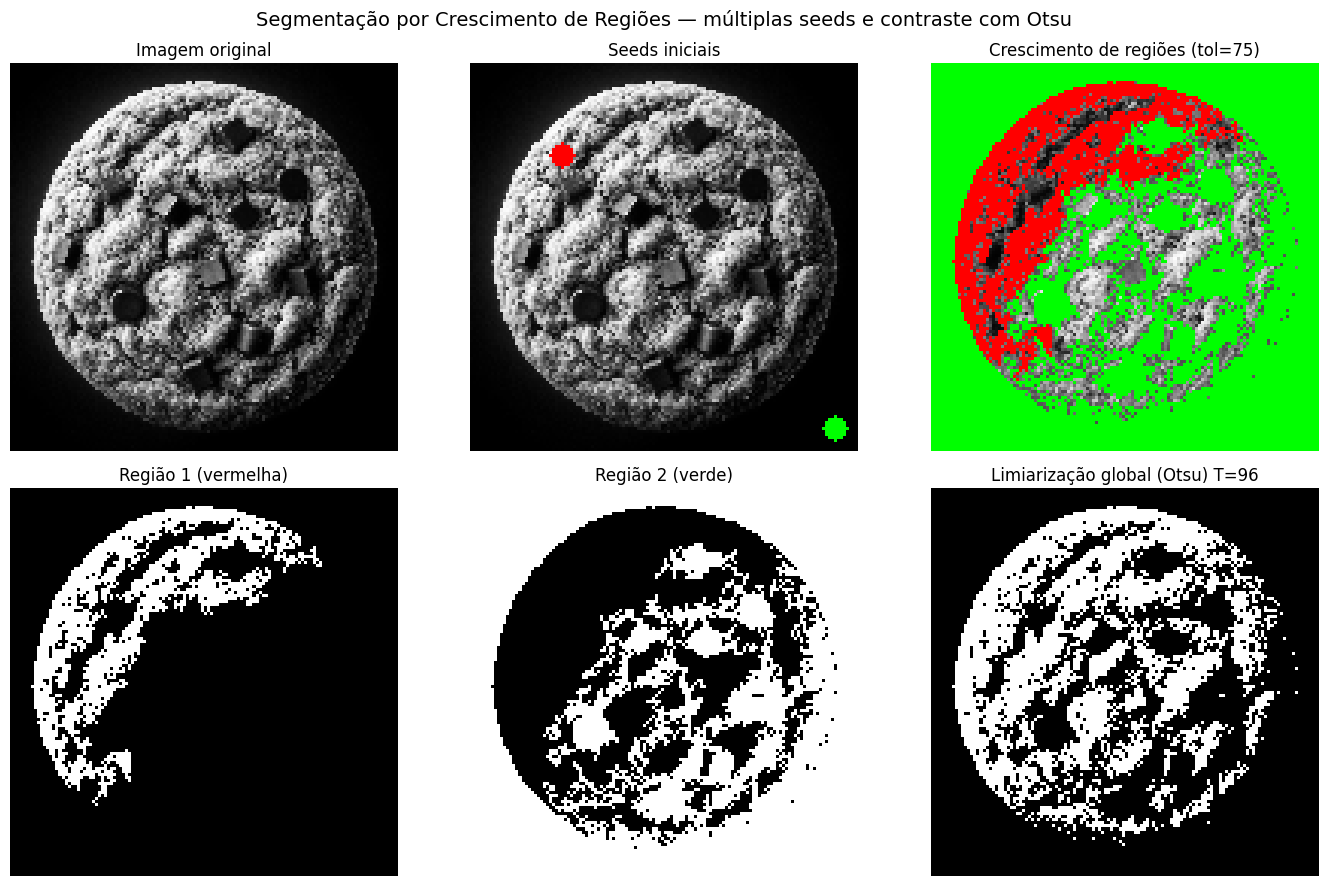

In [12]:
def region_grow(img, seed, tol):
    visited = np.zeros_like(img, dtype=bool)
    region = np.zeros_like(img, dtype=bool)
    seed_val = int(img[seed])
    queue = [seed]
    visited[seed] = True
    region[seed] = True

    while queue:
        x, y = queue.pop(0)
        for dx in [-1, 0, 1]:
            for dy in [-1, 0, 1]:
                if dx == 0 and dy == 0:
                    continue
                xn, yn = x + dx, y + dy
                if 0 <= xn < img.shape[0] and 0 <= yn < img.shape[1] and not visited[xn, yn]:
                    if abs(int(img[xn, yn]) - seed_val) <= tol:
                        region[xn, yn] = True
                        queue.append((xn, yn))
                    visited[xn, yn] = True
    return region

img_in = img_cookie
img_in = cv2.resize(img_in, (128, 128))
img_in = (img_in / img_in.max() * 255).astype(np.uint8)

seeds = [(30, 30), (120, 120)]
tol = 75

mask1 = region_grow(img_in, seeds[0], tol)
mask2 = region_grow(img_in, seeds[1], tol)

regions_map = np.zeros_like(img_in, dtype=np.uint8)
regions_map[mask1] = 1
regions_map[mask2] = 2

overlay = cv2.cvtColor(img_in, cv2.COLOR_GRAY2BGR)
overlay[mask1] = [255, 0, 0]   # vermelho
overlay[mask2] = [0, 255, 0]   # verde

T_otsu = filters.threshold_otsu(img_in)
binary_otsu = (img_in > T_otsu).astype(np.uint8) * 255

fig, axes = plt.subplots(2, 3, figsize=(14, 9))

axes[0,0].imshow(img_in, cmap='gray')
axes[0,0].set_title('Imagem original')
axes[0,0].axis('off')

img_marked = cv2.cvtColor(img_in, cv2.COLOR_GRAY2BGR)
for s, c in zip(seeds, [(255,0,0), (0,255,0)]):
    cv2.circle(img_marked, (s[1], s[0]), 4, c, -1)
axes[0,1].imshow(img_marked)
axes[0,1].set_title('Seeds iniciais')
axes[0,1].axis('off')

axes[0,2].imshow(overlay)
axes[0,2].set_title(f'Crescimento de regiões (tol={tol})')
axes[0,2].axis('off')

axes[1,0].imshow(mask1, cmap='gray')
axes[1,0].set_title('Região 1 (vermelha)')
axes[1,0].axis('off')

axes[1,1].imshow(mask2, cmap='gray')
axes[1,1].set_title('Região 2 (verde)')
axes[1,1].axis('off')

axes[1,2].imshow(binary_otsu, cmap='gray')
axes[1,2].set_title(f'Limiarização global (Otsu) T={int(T_otsu)}')
axes[1,2].axis('off')

fig.suptitle('Segmentação por Crescimento de Regiões — múltiplas seeds e contraste com Otsu', fontsize=14)
plt.tight_layout()
plt.show()

## 4.1.11 Divisão recursiva (quadtree)

Esta célula apresenta a técnica de **segmentação por Quadtree**, que divide a imagem em regiões progressivamente menores de acordo com um critério de **homogeneidade estatística**. O método baseia-se no princípio de subdividir recursivamente a imagem em quatro quadrantes sempre que a variabilidade local (aqui medida pelo desvio-padrão das intensidades) ultrapassa um limiar. O processo termina quando todas as regiões apresentam variabilidade inferior ao limiar, ou quando o tamanho mínimo permitido é atingido.

**Descrição sequencial do código**  
1) A imagem `img_camera` é carregada e redimensionada para 256×256 píxeis para facilitar a subdivisão uniforme.  
2) Define-se a função recursiva `quadtree_split(img, x, y, w, h, threshold, nodes)`:
   - Extrai-se a sub-região definida pelas coordenadas e dimensões `(x, y, w, h)`.  
   - Se a região for demasiado pequena (`w <= 2` ou `h <= 2`), é considerada homogénea e adicionada à lista `nodes`.  
   - Caso contrário, calcula-se o desvio-padrão local `std`.  
   - Se `std > threshold`, a região é subdividida em quatro quadrantes:
     1. superior esquerdo,
     2. superior direito,
     3. inferior esquerdo,
     4. inferior direito.  
     A função é chamada recursivamente para cada quadrante.  
   - Se `std <= threshold`, a região é considerada homogénea e adicionada tal como está.  
3) Define-se uma lista de limiares `[10, 30, 50]` para observar o efeito da tolerância à heterogeneidade.  
4) Para cada limiar:
   - Inicia-se a lista `nodes` vazia e executa-se `quadtree_split` na imagem completa.  
   - Gera-se uma imagem segmentada (`seg`) atribuindo a cada região o valor médio das intensidades dentro dela, obtendo uma versão suavizada da imagem.  
   - Cria-se uma sobreposição (`overlay`) colorida da imagem original, desenhando retângulos azuis sobre os limites das subdivisões para visualizar a granularidade da segmentação.  
5) Organiza-se uma figura 2×(n+1) com as seguintes colunas:
   - (1,1) Imagem original.  
   - (2,1) Original repetida para referência.  
   - Restantes colunas:  
     - Linha 1: sobreposição com subdivisões (para cada limiar).  
     - Linha 2: imagem segmentada correspondente (média local).  
6) Define-se o título global “Segmentação por Quadtree — efeito do limiar de homogeneidade (std)” e exibe-se a figura.

**Interpretação e observações**  
O método de Quadtree é útil quando se pretende uma **segmentação hierárquica** baseada na variabilidade local. Regiões com desvio-padrão baixo são tratadas como homogéneas, enquanto áreas com textura ou fronteiras intensas são subdivididas até atingirem a homogeneidade definida.  
A variação do parâmetro `threshold` controla o nível de detalhe:
- Com limiar baixo (e.g., 10), surgem muitas subdivisões finas — maior detalhe e maior custo computacional.  
- Com limiar alto (e.g., 50), a imagem é descrita por poucas regiões largas — menos detalhe mas maior suavização.  
O resultado mostra a progressiva fusão das regiões conforme o limiar aumenta, evidenciando o compromisso entre precisão espacial e homogeneidade estatística. Este tipo de segmentação é particularmente útil como etapa inicial em algoritmos de compressão, reconhecimento de padrões ou análise estrutural de imagens.

/var/folders/rs/54dlntxs0m16mcwwztsk82880000gn/T/ipykernel_67153/55387287.py:53: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.95])


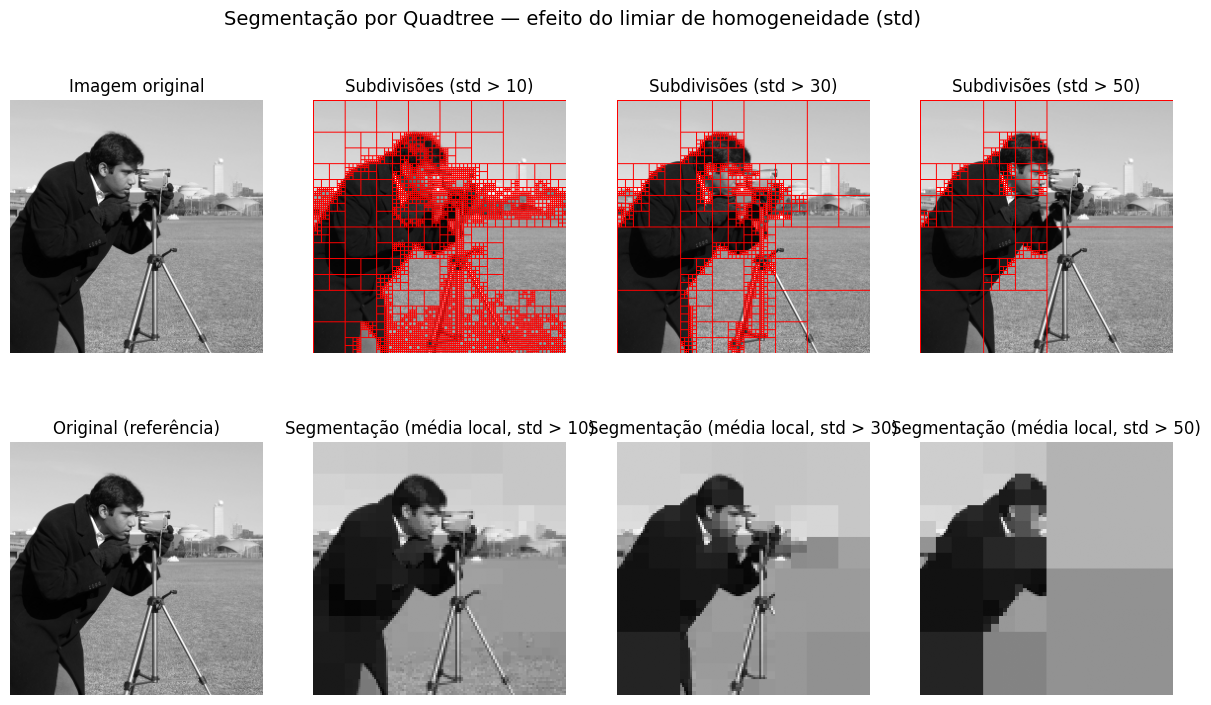

In [13]:
img_in = img_camera
img_in = cv2.resize(img_in, (256, 256))

def quadtree_split(img, x, y, w, h, threshold, nodes):
    region = img[y:y+h, x:x+w]
    if w <= 2 or h <= 2:
        nodes.append((x, y, w, h))
        return
    std = region.std()
    if std > threshold:
        half_w = w // 2
        half_h = h // 2
        quadtree_split(img, x, y, half_w, half_h, threshold, nodes)
        quadtree_split(img, x + half_w, y, w - half_w, half_h, threshold, nodes)
        quadtree_split(img, x, y + half_h, half_w, h - half_h, threshold, nodes)
        quadtree_split(img, x + half_w, y + half_h, w - half_w, h - half_h, threshold, nodes)
    else:
        nodes.append((x, y, w, h))

thresholds = [10, 30, 50]
fig, axes = plt.subplots(2, len(thresholds)+1, figsize=(15, 8), gridspec_kw={'hspace': 0.25})

axes[0,0].imshow(img_in, cmap='gray')
axes[0,0].set_title('Imagem original')
axes[0,0].axis('off')

axes[1,0].imshow(img_in, cmap='gray')
axes[1,0].set_title('Original (referência)')
axes[1,0].axis('off')

for i, t in enumerate(thresholds):
    nodes = []
    quadtree_split(img_in, 0, 0, img_in.shape[1], img_in.shape[0], t, nodes)
    
    seg = np.zeros_like(img_in, dtype=np.uint8)
    for (x, y, w, h) in nodes:
        seg[y:y+h, x:x+w] = int(img_in[y:y+h, x:x+w].mean())
    
    # Overlay de divisões
    overlay = cv2.cvtColor(img_in, cv2.COLOR_GRAY2BGR)
    for (x, y, w, h) in nodes:
        cv2.rectangle(overlay, (x, y), (x+w, y+h), (255, 0, 0), 1)

    axes[0, i+1].imshow(overlay)
    axes[0, i+1].set_title(f'Subdivisões (std > {t})')
    axes[0, i+1].axis('off')

    axes[1, i+1].imshow(seg, cmap='gray', vmin=0, vmax=255)
    axes[1, i+1].set_title(f'Segmentação (média local, std > {t})')
    axes[1, i+1].axis('off')

fig.suptitle('Segmentação por Quadtree — efeito do limiar de homogeneidade (std)', fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

## 4.1.12 Watershed

Na primeira célula desta secção demonstramos o funcionamento do algoritmo **Watershed** para segmentação baseada em gradiente, comparando duas abordagens de inicialização: uma automática (com limiar de Otsu) e outra manual (com marcadores definidos pelo utilizador). O método Watershed interpreta a imagem como uma topografia, onde os valores de intensidade correspondem a alturas — as regiões são “alagadas” a partir de marcadores iniciais até que as frentes de expansão se encontrem, delimitando fronteiras de objetos.

**Descrição sequencial do código**  
1) A imagem `img_building` é carregada e redimensionada para 256×256 píxeis.  
2) Calcula-se o **gradiente** da imagem com o operador de Sobel (`filters.sobel`), resultando numa imagem em escala de cinzento que evidencia bordas e transições de intensidade — zonas de alto gradiente correspondem a potenciais fronteiras entre regiões.  
3) Determina-se um limiar global de intensidade usando o método de Otsu (`threshold_otsu`).  
4) Cria-se a matriz `markers_auto` com dois rótulos iniciais:  
   - valor 1 para píxeis com intensidade abaixo do limiar (fundo);  
   - valor 2 para píxeis acima do limiar (objetos).  
5) Executa-se o algoritmo Watershed (`segmentation.watershed`) sobre o mapa de gradientes `grad`, utilizando os marcadores automáticos. O resultado `labels_auto` é uma matriz de rótulos indicando as regiões segmentadas.  
6) Gera-se uma sobreposição colorida (`overlay_auto`) com `label2rgb`, fundindo as regiões identificadas com a imagem original para visualização intuitiva.  
7) Cria-se um conjunto de **marcadores manuais** desenhando círculos em coordenadas predefinidas (`coords`), simulando seeds escolhidas pelo utilizador. Cada marcador recebe um identificador distinto (1, 2, 3, ...).  
8) Aplica-se novamente o algoritmo Watershed, desta vez com os marcadores manuais, obtendo `labels_manual` e a respetiva sobreposição colorida `overlay_manual`.  
9) Constrói-se uma figura 2×3 com os seguintes subplots:  
   - (1,1) Imagem original.  
   - (1,2) Mapa do gradiente de Sobel.  
   - (1,3) Mapa de marcadores automáticos criados com Otsu.  
   - (2,1) Resultado do Watershed automático.  
   - (2,2) Resultado do Watershed automático sobreposto à imagem original.  
   - (2,3) Resultado do Watershed com marcadores manuais, evidenciando a influência da escolha inicial.  
10) Define-se o título global “Segmentação por Watershed — efeito dos marcadores” e exibe-se a figura final.

**Interpretação e observações**  
O algoritmo Watershed é poderoso para **separar objetos adjacentes** e detetar fronteiras em imagens de gradiente, mas o resultado depende fortemente dos marcadores iniciais.  
- No modo **automático**, os marcadores derivados do limiar de Otsu fornecem uma segmentação genérica, mas podem confundir áreas com intensidades semelhantes ou gradientes suaves.  
- No modo **manual**, o utilizador pode posicionar marcadores de forma mais informada, controlando a formação e extensão das regiões resultantes.  
O gradiente atua como mapa topográfico, e as linhas de divisão correspondem às “cristas” que separam as bacias de drenagem.  
Para melhorar a segmentação, pode-se:  
- aplicar uma **suavização prévia** (para reduzir ruído);  
- combinar o gradiente com **operações morfológicas** (para refinar marcadores);  
- ou usar técnicas híbridas (e.g., Watershed sobre mapas de distância ou gradiente invertido).  
Esta abordagem é particularmente útil em imagens de células, arquitetura ou relevo, onde fronteiras naturais estão bem definidas por variações de intensidade.

Na segunda célula apresentamos uma versão **progressiva do algoritmo Watershed**, ilustrando o processo de inundação (*flooding*) ao longo de diferentes níveis do gradiente. A ideia é visualizar como as regiões crescem gradualmente a partir dos marcadores iniciais, “alagando” o relevo de intensidades até que as fronteiras (linhas de crista) se encontrem. O gradiente atua como mapa topográfico, e os limiares sucessivos controlam a profundidade da inundação.

**Descrição sequencial do código**  
1) A imagem `img_coins` é carregada, redimensionada para 256×256 píxeis e convertida para `float` para permitir cálculos contínuos.  
2) Calcula-se o gradiente de Sobel (`filters.sobel`), que serve de mapa de relevo: valores baixos correspondem a áreas planas (fundo das bacias) e valores altos a bordas (cristas).  
3) Determina-se o limiar de Otsu (`threshold_otsu`) e criam-se marcadores binários (`markers`):  
   - píxeis abaixo do limiar recebem rótulo 1 (fundo);  
   - píxeis acima do limiar recebem rótulo 2 (objetos).  
4) Define-se a função `watershed_until(level)`, que executa o algoritmo Watershed **restrito a zonas com gradiente inferior ou igual a um nível especificado**.  
   - Uma cópia do gradiente é criada.  
   - Os píxeis com gradiente acima do nível `level` são definidos como `np.inf`, formando barreiras intransponíveis.  
   - O Watershed é executado apenas dentro da máscara `mask = g <= level`, simulando uma inundação que se expande até esse limite.  
5) Três níveis de inundação são definidos com base nos percentis do gradiente:  
   - $P_{20}$ (início da inundação),  
   - $P_{50}$ (meio da inundação),  
   - $P_{99}$ (inundação quase total).  
6) A função `watershed_until` é chamada para cada um desses níveis, retornando os rótulos (`L1`, `L2`, `L3`) e as máscaras correspondentes (`M1`, `M2`, `M3`).  
7) Gera-se uma visualização colorida de cada resultado com `label2rgb`, sobrepondo as regiões segmentadas à imagem original.  
8) Cria-se uma figura 2×3 com os seguintes subplots:  
   - (1,1) Imagem original.  
   - (1,2) Gradiente interpretado como relevo topográfico.  
   - (1,3) Marcadores iniciais (fundo e objeto).  
   - (2,1) Resultado da inundação inicial (nível ≈ P20).  
   - (2,2) Inundação a meio (nível ≈ P50).  
   - (2,3) Inundação quase total (nível ≈ P99).  
9) Define-se o título global “Watershed — inundação progressiva (flooding)” e exibe-se a figura final.

**Interpretação e observações**  
Esta visualização oferece uma metáfora direta para o funcionamento do Watershed: as regiões começam a crescer nas depressões locais (marcadores) e expandem-se gradualmente à medida que o nível de “água” sobe. Quando duas frentes se encontram, uma **linha de crista** é traçada, delimitando as fronteiras.  
- No início (P20), apenas as áreas de gradiente baixo — planas e homogéneas — são preenchidas.  
- No meio (P50), as regiões expandem e começam a aproximar-se das fronteiras.  
- Perto do final (P99), a inundação cobre quase toda a imagem, e as divisórias entre regiões tornam-se nítidas.  
O uso de percentis para controlar o nível de inundação permite observar como a topografia do gradiente influencia a segmentação. Este exercício ajuda a compreender que o Watershed é essencialmente um processo hierárquico e contínuo, e que os marcadores iniciais e a suavização prévia do gradiente são determinantes na qualidade e estabilidade das fronteiras obtidas.

/var/folders/rs/54dlntxs0m16mcwwztsk82880000gn/T/ipykernel_67153/2964237055.py:33: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.95])


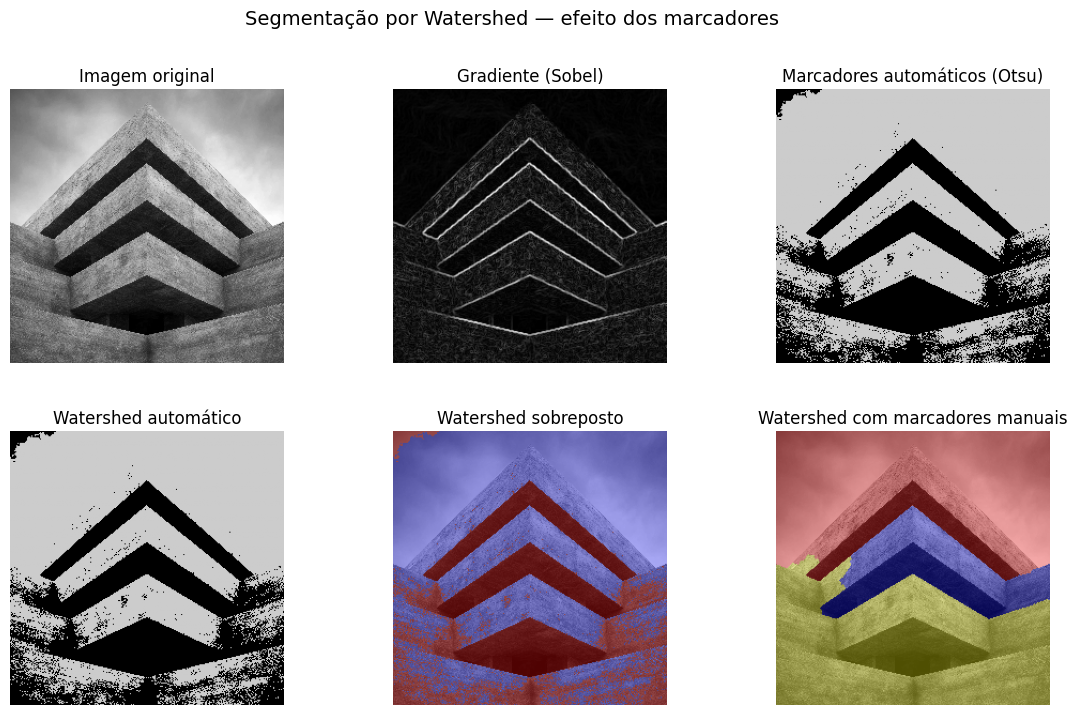

In [14]:
img_in = img_building
img_in = cv2.resize(img_in, (256, 256))

grad = filters.sobel(img_in.astype(float))

t = threshold_otsu(img_in)
markers_auto = np.zeros_like(img_in, dtype=np.int32)
markers_auto[img_in < t] = 1   # fundo
markers_auto[img_in >= t] = 2  # objetos

labels_auto = segmentation.watershed(grad, markers_auto)
overlay_auto = label2rgb(labels_auto, image=img_in, bg_label=0)

manual = np.zeros_like(img_in, dtype=np.int32)
coords = [(80, 80), (120, 150), (180, 70)]  # marcadores exemplo
for i, (y, x) in enumerate(coords, start=1):
    cv2.circle(manual, (x, y), 8, i, -1)

labels_manual = segmentation.watershed(grad, manual)
overlay_manual = label2rgb(labels_manual, image=img_in, bg_label=0)

fig, axes = plt.subplots(2, 3, figsize=(14, 8), gridspec_kw={'hspace': 0.25})

axes[0,0].imshow(img_in, cmap='gray'); axes[0,0].set_title('Imagem original'); axes[0,0].axis('off')
axes[0,1].imshow(grad, cmap='gray'); axes[0,1].set_title('Gradiente (Sobel)'); axes[0,1].axis('off')
axes[0,2].imshow(markers_auto, cmap='nipy_spectral'); axes[0,2].set_title('Marcadores automáticos (Otsu)'); axes[0,2].axis('off')

axes[1,0].imshow(labels_auto, cmap='nipy_spectral'); axes[1,0].set_title('Watershed automático'); axes[1,0].axis('off')
axes[1,1].imshow(overlay_auto); axes[1,1].set_title('Watershed sobreposto'); axes[1,1].axis('off')
axes[1,2].imshow(overlay_manual); axes[1,2].set_title('Watershed com marcadores manuais'); axes[1,2].axis('off')

fig.suptitle('Segmentação por Watershed — efeito dos marcadores', fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

/var/folders/rs/54dlntxs0m16mcwwztsk82880000gn/T/ipykernel_67153/2813413985.py:43: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0,0,1,0.95])


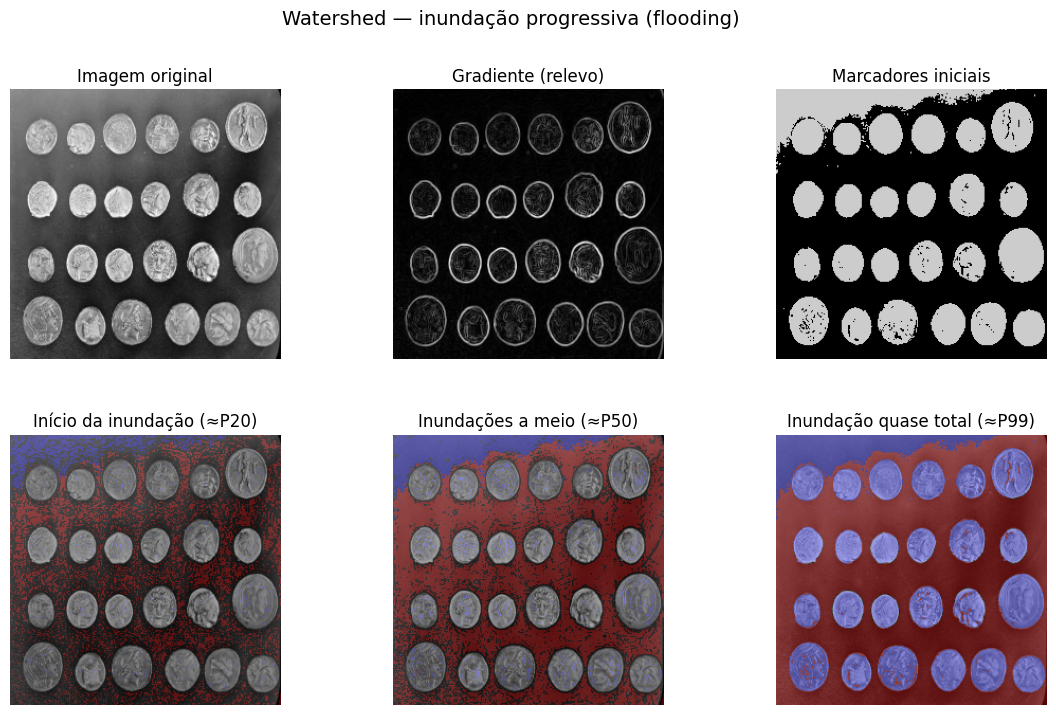

In [15]:
img = img_coins
img = cv2.resize(img, (256, 256))

grad = filters.sobel(img.astype(float))

t = threshold_otsu(img)
markers = np.zeros_like(img, dtype=np.int32)
markers[img < t]  = 1
markers[img >= t] = 2

def watershed_until(level):
    """
    Executa watershed apenas nas zonas com gradiente <= level.
    O resto é 'bloqueado' (np.inf), impedindo a inundação de passar.
    """
    g = grad.copy()
    mask = g <= level
    g[~mask] = np.inf           # barreiras intransponíveis acima do nível
    labels = segmentation.watershed(g, markers, mask=mask)
    return labels, mask

lev_start, lev_mid, lev_full = np.percentile(grad, [20, 50, 99])

L1, M1 = watershed_until(lev_start)   # início
L2, M2 = watershed_until(lev_mid)     # meio
L3, M3 = watershed_until(lev_full)    # quase total (resultado final)

ov1 = label2rgb(L1, image=img, bg_label=0)
ov2 = label2rgb(L2, image=img, bg_label=0)
ov3 = label2rgb(L3, image=img, bg_label=0)

fig, axes = plt.subplots(2, 3, figsize=(14, 8), gridspec_kw={'hspace': 0.28})

axes[0,0].imshow(img, cmap='gray');               axes[0,0].set_title('Imagem original'); axes[0,0].axis('off')
axes[0,1].imshow(grad, cmap='gray');              axes[0,1].set_title('Gradiente (relevo)'); axes[0,1].axis('off')
axes[0,2].imshow(markers, cmap='nipy_spectral');  axes[0,2].set_title('Marcadores iniciais'); axes[0,2].axis('off')

axes[1,0].imshow(ov1); axes[1,0].set_title('Início da inundação (≈P20)'); axes[1,0].axis('off')
axes[1,1].imshow(ov2); axes[1,1].set_title('Inundações a meio (≈P50)');  axes[1,1].axis('off')
axes[1,2].imshow(ov3); axes[1,2].set_title('Inundação quase total (≈P99)'); axes[1,2].axis('off')

fig.suptitle('Watershed — inundação progressiva (flooding)', fontsize=14)
plt.tight_layout(rect=[0,0,1,0.95])
plt.show()

## 4.1.13 Comparar diferentes métodos de binarização e segmentação

Esta célula apresenta uma **análise comparativa de métodos de binarização** — Otsu, Multi-Otsu, Adaptativo e Watershed — avaliando desempenho visual, estatístico e computacional. O objetivo é observar as diferenças entre abordagens globais, locais e baseadas em gradiente, tanto em termos de qualidade (área branca e conectividade) como de custo de execução. Inclui-se ainda um estudo da **robustez ao ruído** do método de Otsu.

**Descrição sequencial do código**  
1) A imagem `img_coins` é carregada, redimensionada e convertida para `uint8`. Calcula-se também o gradiente com o operador Sobel, usado pelo método Watershed.  
2) Define-se a função `evaluate_method(binary_img)`, que calcula duas métricas simples:
   - **Proporção de branco** — fração de píxeis binários com valor 1 (ou 255), equivalente à área segmentada.  
   - **Número de regiões conexas** — obtido com `cv2.connectedComponents`, que indica quantas regiões independentes foram detetadas.  
3) A função `timed(func, *args, **kwargs)` mede o tempo de execução (em milissegundos) de qualquer função, devolvendo o resultado e a duração.  
4) São implementados quatro métodos de binarização:
   - `otsu_method`: limiarização global automática de Otsu.  
   - `multi_otsu_method`: extensão multi-nível com três classes, mantendo apenas a mais clara.  
   - `adaptive_method`: limiarização adaptativa gaussiana, sensível a variações locais de iluminação (`block=35`, `C=5`).  
   - `watershed_method`: segmentação por Watershed aplicada sobre o gradiente, usando limiar de Otsu para definir marcadores de fundo e objeto.  
5) Cada método é aplicado à imagem dentro de um laço, sendo recolhidos:  
   - a imagem binária resultante,  
   - o tempo de execução,  
   - a proporção de branco,  
   - e o número de regiões conexas.  
6) Gera-se uma figura 1×4 com os resultados visuais de cada método, permitindo comparação direta.  
7) Constrói-se um gráfico de barras duplo:  
   - eixo esquerdo (cinzento): proporção de branco;  
   - eixo direito (azul): número de regiões conexas;  
   - o gráfico ilustra o compromisso entre área segmentada e fragmentação de regiões.  
8) Mostra-se um gráfico separado com o **tempo médio de execução** (ms) de cada método, permitindo avaliar a sua eficiência relativa.  
9) Na segunda parte, analisa-se o comportamento do **método de Otsu sob ruído gaussiano**:
   - gera-se ruído com desvio-padrão $\sigma = [5, 15, 30, 60]$;  
   - mede-se o limiar resultante $T_{otsu}$ e o tempo de execução para cada nível;  
   - os resultados são apresentados em dois gráficos: “Limiar vs σ do ruído” e “Tempo vs σ do ruído”.

**Interpretação e observações**  
A comparação evidencia as diferenças fundamentais entre os métodos:  
- **Otsu (global)** — rápido e estável em imagens bimodais, mas sensível a ruído e iluminação irregular.  
- **Multi-Otsu** — separa múltiplas faixas tonais, útil em imagens com três classes distintas (fundo-objeto-intermédio).  
- **Adaptativo** — ajusta-se localmente, lidando melhor com sombras ou gradientes de luz, embora possa introduzir ruído fino e fragmentação.  
- **Watershed** — mais complexo e computacionalmente pesado, mas capaz de identificar fronteiras precisas em imagens estruturadas, especialmente quando combinado com pré-processamento adequado.  

O gráfico de ruído mostra que Otsu mantém limiares relativamente estáveis até níveis moderados de ruído, mas tende a flutuar quando a variância aumenta, refletindo uma perda de separabilidade tonal. O tempo de execução cresce ligeiramente com o ruído, devido ao aumento da irregularidade no histograma.  

No conjunto, esta análise demonstra a **trade-off** entre precisão, robustez e custo computacional — nenhuma técnica é universalmente superior, e a escolha deve ser guiada pelas condições de iluminação, nível de ruído e natureza das estruturas a segmentar.

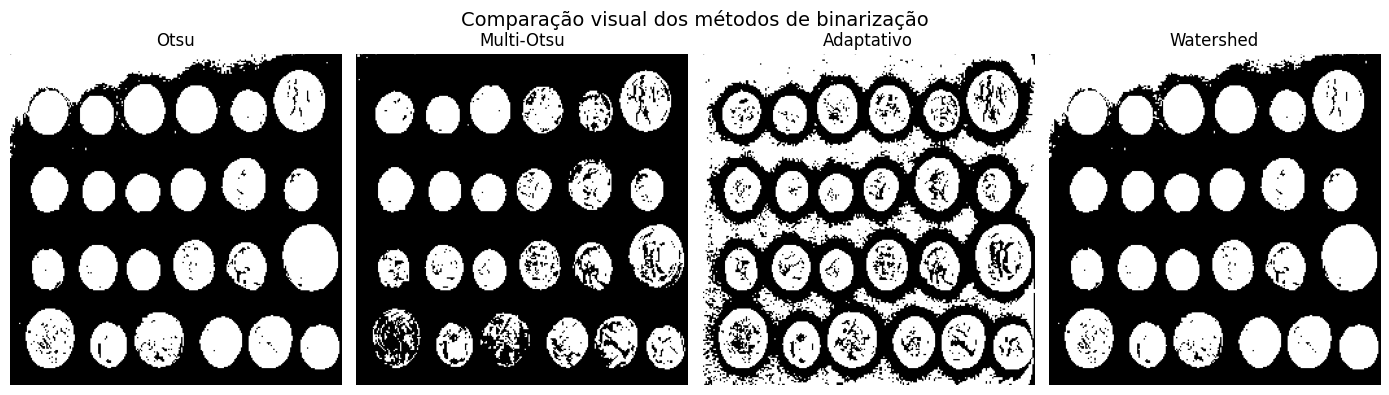

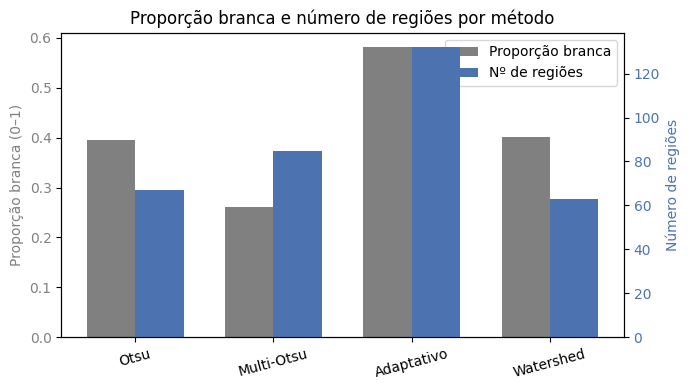

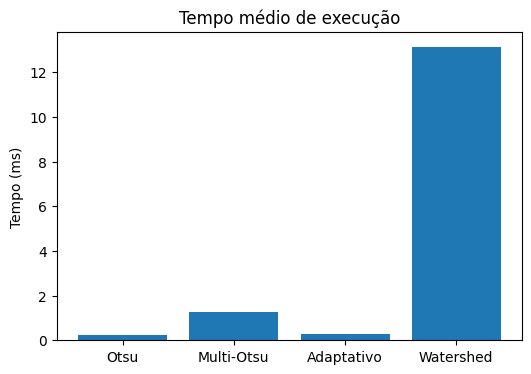

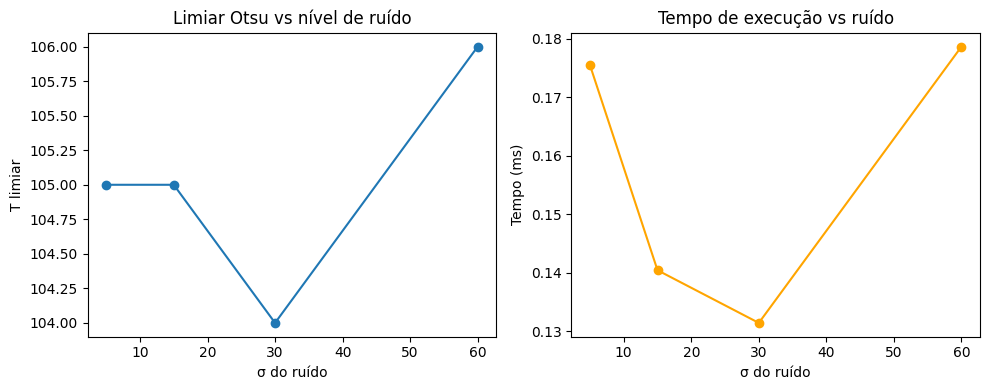

In [16]:
img_in = img_coins
img_in = cv2.resize(img_in, (256, 256))
grad_in = filters.sobel(img_in.astype(float))

def evaluate_method(binary_img):
    """Retorna proporção de branco e nº de regiões conexas."""
    ratio = np.mean(binary_img > 0)
    num_regions, _ = cv2.connectedComponents(binary_img.astype(np.uint8))
    return ratio, num_regions

def timed(func, *args, **kwargs):
    """Mede tempo de execução (ms) de uma função."""
    start = time.perf_counter()
    result = func(*args, **kwargs)
    elapsed = (time.perf_counter() - start) * 1000
    return result, elapsed

def otsu_method(img):
    thr = threshold_otsu(img)
    return (img > thr).astype(np.uint8) * 255

def multi_otsu_method(img):
    thr = threshold_multiotsu(img, classes=3)
    seg = np.digitize(img, thr)
    return (seg == 2).astype(np.uint8) * 255

def adaptive_method(img, block=35, C=5):
    return cv2.adaptiveThreshold(img, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                 cv2.THRESH_BINARY, block, C)

def watershed_method(img):
    grad = filters.sobel(img.astype(float))
    thr = threshold_otsu(img)
    markers = np.zeros_like(img, dtype=np.int32)
    markers[img < thr] = 1
    markers[img >= thr] = 2
    labels = segmentation.watershed(grad, markers)
    return (labels > 1).astype(np.uint8) * 255

methods = {
    "Otsu": otsu_method,
    "Multi-Otsu": multi_otsu_method,
    "Adaptativo": adaptive_method,
    "Watershed": watershed_method
}

ratios, regions, times = {}, {}, {}
binaries = {}

for name, func in methods.items():
    bin_img, t = timed(func, img_in)
    binaries[name] = bin_img
    times[name] = t
    r, c = evaluate_method(bin_img)
    ratios[name] = r
    regions[name] = c

fig, axes = plt.subplots(1, 4, figsize=(14, 4))
for ax, (name, img) in zip(axes, binaries.items()):
    ax.imshow(img, cmap='gray', vmin=0, vmax=255)
    ax.set_title(f'{name}')
    ax.axis('off')
fig.suptitle('Comparação visual dos métodos de binarização', fontsize=14)
plt.tight_layout()
plt.show()

fig, ax1 = plt.subplots(figsize=(7, 4))
x = np.arange(len(methods))
width = 0.35

ax1.bar(x - width/2, [ratios[m] for m in methods], width,
        label='Proporção branca', color='gray')
ax1.set_ylabel('Proporção branca (0–1)', color='gray')
ax1.tick_params(axis='y', labelcolor='gray')

ax2 = ax1.twinx()
ax2.bar(x + width/2, [regions[m] for m in methods], width,
        label='Nº de regiões', color='#4C72B0')
ax2.set_ylabel('Número de regiões', color='#4C72B0')
ax2.tick_params(axis='y', labelcolor='#4C72B0')

ax1.set_xticks(x)
ax1.set_xticklabels(methods.keys(), rotation=15)
ax1.set_title('Proporção branca e número de regiões por método')

handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(handles1 + handles2, labels1 + labels2, loc='upper right')

plt.tight_layout()
plt.show()

fig, ax2 = plt.subplots(figsize=(6, 4))
ax2.bar(methods.keys(), [times[m] for m in methods])
ax2.set_ylabel('Tempo (ms)')
ax2.set_title('Tempo médio de execução')
plt.show()

noise_levels = [5, 15, 30, 60]
thr_values, time_values = [], []
for sigma in noise_levels:
    noisy = np.clip(img_in + np.random.normal(0, sigma, img_in.shape), 0, 255).astype(np.uint8)
    _, t = timed(threshold_otsu, noisy)
    thr_values.append(threshold_otsu(noisy))
    time_values.append(t)

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].plot(noise_levels, thr_values, marker='o')
ax[0].set_title('Limiar Otsu vs nível de ruído')
ax[0].set_xlabel('σ do ruído')
ax[0].set_ylabel('T limiar')
ax[1].plot(noise_levels, time_values, marker='o', color='orange')
ax[1].set_title('Tempo de execução vs ruído')
ax[1].set_xlabel('σ do ruído')
ax[1].set_ylabel('Tempo (ms)')
plt.tight_layout()
plt.show()